# **TASK 1**

### Loading Dataset

In [1]:
import zipfile
import pandas as pd
from pathlib import Path

# Path to the uploaded ZIP file
zip_path = "/content/afl_datasets.zip"

# Open the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:

    # Show all files inside the ZIP
    print("Files inside the AFL dataset:")
    for file in zip_ref.namelist():
        print(file)

Files inside the AFL dataset:
afl_datasets/afl_players_info_raw.csv
afl_datasets/afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv
afl_datasets/afl_players_seasonal_stats_raw.csv
afl_datasets/team_matches_home_away_raw - team_matches_home_away_raw.csv.csv


In [4]:
with zipfile.ZipFile(zip_path, "r") as zip_ref:

    player_info = pd.read_csv(
        zip_ref.open("afl_datasets/afl_players_info_raw.csv")
    )

    player_round = pd.read_csv(
        zip_ref.open(
            "afl_datasets/afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv"
        )
    )

    player_season = pd.read_csv(
        zip_ref.open("afl_datasets/afl_players_seasonal_stats_raw.csv")
    )

    team_matches = pd.read_csv(
        zip_ref.open(
            "afl_datasets/team_matches_home_away_raw - team_matches_home_away_raw.csv.csv"
        )
    )

print("All datasets loaded successfully.")

All datasets loaded successfully.


/tmp/ipykernel_7668/2842966419.py:13: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  player_season = pd.read_csv(


### Getting Tables Info

In [5]:
# Checking Size
print("Player Info:", player_info.shape)
print("Player Round-by-Round Stats:", player_round.shape)
print("Player Seasonal Stats:", player_season.shape)
print("Team Matches:", team_matches.shape)

Player Info: (2848, 16)
Player Round-by-Round Stats: (274089, 36)
Player Seasonal Stats: (25491, 54)
Team Matches: (15808, 19)


In [8]:
# Getting Columns
print("===== PLAYER INFO =====")
print(player_info.columns.tolist)

print("\n===== PLAYER ROUND STATS =====")
print(player_round.columns.tolist())

print("\n===== PLAYER SEASONAL STATS =====")
print(player_season.columns.tolist())

print("\n===== TEAM MATCHES =====")
print(team_matches.columns.tolist())

===== PLAYER INFO =====
<bound method IndexOpsMixin.tolist of Index(['id', 'player_name', 'player_full_name', 'first_name', 'last_name',
       'born_date', 'debut_date', 'debut_age', 'last_date', 'last_age',
       'height', 'weight', 'profile_pic', 'player_link', 'player_common_names',
       'player_teams'],
      dtype='object')>

===== PLAYER ROUND STATS =====
['id', 'team', 'year', 'career_game_count', 'opponent', 'round', 'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date', 'fantasy_points', 'score', 'margin']

===== PLAYER SEASONAL STATS =====
['player_id', 'year', 'team', 'is_finals', 'games_played', 'kicks', 'marks', 'han

### Dataset Grain



| Dataset | Grain | Description |
|---|---|---|
| Player Info | One row per player | Contains player-level profile information |
| Player Round-by-Round Stats | One row per player per match | Contains individual player performance for each game |
| Player Seasonal Stats | One row per player per season/team/finals status | Contains aggregated player statistics across a season |
| Team Matches | One row per team per match | Contains team performance, opponent, venue, score and result |

### Important observation

The Team Matches dataset contains two rows for a single real match:
one row for the home team and one row for the away team.

Therefore:

    Team-match rows / 2 = approximately actual matches

The Player Round-by-Round dataset is the main source for player-level prediction targets, while Team Matches is the main source for match-level prediction targets.

### Getting First Five Rows

In [10]:
display(player_info.head())
display(player_round.head())
display(player_season.head())
display(team_matches.head())

,id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,NaN,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
1,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87,NaN,https://afltables.com/afl/stats/players/G/Gary...,NaN,"{Geelong Cats,Gold Coast Suns}"
2,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,195,85,https://res.cloudinary.com/dijzdikkh/image/upl...,https://afltables.com/afl/stats/players/L/Leek...,NaN,NaN
3,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,195,95,NaN,https://afltables.com/afl/stats/players/N/Nath...,NaN,"{Geelong Cats,Gold Coast Suns}"
4,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,196,101,NaN,https://afltables.com/afl/stats/players/C/Cain...,NaN,"{Carlton Blues,Port Adelaide Power,St Kilda Sa..."


,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25


,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,6.7,6.7,0.3,1.7,4.3,0.0,0.3,6.7,92.7,84.3
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1.0,61.0,81.0
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6.0,74.0,83.0
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6.0,22.0,54.0
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,5.7,3.0,0.3,0.3,1.0,0.2,0.0,5.3,36.9,NaN


,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
0,15807,Hawthorn Hawks,QF,1994-09-10,1994,A,North Melbourne Kangaroos,4.5 5.7 10.11 13.13 13.13 13.13,91,2.3 6.12 9.12 12.19 13.23 15.24,114,L,23,Waverley Park,38223.0,13,13,15,24
1,15808,North Melbourne Kangaroos,QF,1994-09-10,1994,H,Hawthorn Hawks,2.3 6.12 9.12 12.19 13.23 15.24,114,4.5 5.7 10.11 13.13 13.13 13.13,91,W,6,Waverley Park,38223.0,15,24,13,13
2,5646,North Melbourne Kangaroos,10,2008-05-31,2008,A,Brisbane Lions,2.2 6.2 12.3 15.8,98,4.7 11.12 15.17 18.21,129,L,-31,The Gabba,22118.0,15,8,18,21
3,8829,Sydney Swans,15,2017-06-30,2017,A,Melbourne Demons,1.8 5.15 8.16 11.19,85,4.0 4.1 5.4 7.8,50,W,35,Melbourne Cricket Ground,47464.0,11,19,7,8
4,8873,Sydney Swans,11,2019-06-01,2019,A,Geelong Cats,3.3 5.8 6.12 8.15,63,5.1 7.2 11.4 13.7,85,L,-22,GMHBA Stadium,29021.0,8,15,13,7


### Data Range

In [11]:
# Convert match date to datetime
team_matches["match_date"] = pd.to_datetime(
    team_matches["match_date"],
    errors="coerce"
)

print("Earliest match:", team_matches["match_date"].min())
print("Latest match:", team_matches["match_date"].max())

print("\nNumber of seasons:",
      team_matches["year"].nunique())

print("\nSeasons:")
print(sorted(team_matches["year"].dropna().unique()))

Earliest match: 1983-03-26 00:00:00
Latest match: 2025-09-27 00:00:00

Number of seasons: 43

Seasons:
[np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


### Count Teams

In [12]:
teams = sorted(
    set(team_matches["team_name"].dropna().unique())
    |
    set(team_matches["opponent"].dropna().unique())
)

print("Number of unique team names:", len(teams))

print("\nTeams:")
for team in teams:
    print(team)

Number of unique team names: 62

Teams:
	 Adelaide Crows 
	Brisbane Bears
	Brisbane Lions
	Carlton Blues
	Collingwood Magpies
	Essendon Bombers
	Fitzroy Lions
	Fremantle Dockers
	Geelong Cats
	Gold Coast Suns
	Greater Western Sydney Giants
	Hawthorn Hawks
	Melbourne Demons
	North Melbourne Kangaroos
	Port Adelaide Power
	Richmond Tigers
	St Kilda Saints
	Sydney Swans
	W. Bulldogs
	West Coast Eagles
 Adelaide Crows 
Adelaide Crows
Brisbane Bears
Brisbane Lions
Carlton Blues
Collingwood Magpies
Essendon Bombers
Fitzroy Lions
Fremantle Dockers
Geelong Cats
Gold Coast Suns
Greater Western Sydney Giants
Hawthorn Hawks
Melbourne Demons
North Melbourne Kangaroos
Port Adelaide Power
Richmond Tigers
St Kilda Saints
Sydney Swans
W. Bulldogs
West Coast Eagles
Western Bulldogs
adelaide crows
brisbane bears
brisbane lions
carlton blues
collingwood magpies
essendon bombers
fitzroy lions
fremantle dockers
geelong cats
gold coast suns
greater western sydney giants
hawthorn hawks
melbourne demons
north

### How tables Joins

In [9]:
print("Player Info ID:")
print(player_info["id"].head())

print("\nPlayer Round Player ID:")
print(player_round["player_id"].head())

print("\nPlayer Seasonal Player ID:")
print(player_season["player_id"].head())

Player Info ID:
0    43261
1    43262
2    43276
3    43264
4    43265
Name: id, dtype: int64

Player Round Player ID:
0    45552
1    44356
2    45955
3    45656
4    45929
Name: player_id, dtype: int64

Player Seasonal Player ID:
0    43261
1    43261
2    43261
3    43261
4    43262
Name: player_id, dtype: object


## Documentation: Tables, Grain and Joins

The AFL dataset contains four main tables. Each table has a different level of detail (grain), so the tables should not be joined directly without considering their keys.

### 1. afl_players_info_raw.csv

**What each row represents:**  
One AFL player and their biographical/basic information.

**Grain:**  
One row per player.

**Important fields:**
- `player_id` — unique identifier for the player
- Player name fields
- Other player information fields

**Primary join key:**  
`player_id`

**Can join with:**
- `afl_players_round_by_round_stats_raw` using `player_id`
- `afl_players_seasonal_stats_raw` using `player_id`

**Limitation:**  
Some player IDs appearing in the performance tables are not present in this player information table.

---

### 2. afl_players_round_by_round_stats_raw

**What each row represents:**  
One player's statistics for one AFL match/round.

**Grain:**  
One row per player per match/round (player-game level).

**Important fields:**
- `player_id` — identifies the player
- `team` — player's team
- `opponent` — opposing team
- `match_date` — match date
- `season` — AFL season
- `round` — competition round
- Player performance statistics such as disposals, goals, marks, tackles and fantasy points

**Primary join keys:**
- `player_id`
- `season`
- `round`
- `match_date`
- Team/opponent context

**Can join with:**
- `afl_players_info_raw` using `player_id`
- `afl_players_seasonal_stats_raw` using `player_id` and `season`
- Team match data using the match context: `season`, `round`, `match_date`, team and opponent

**Important limitation:**  
There is no explicit `match_id` in the raw data. Therefore, a match identifier must be reconstructed using available match-context fields such as date, season/round, teams and opponent.

---

### 3. afl_players_seasonal_stats_raw.csv

**What each row represents:**  
One player's aggregated statistics for one AFL season.

**Grain:**  
One row per player per season (player-season level).

**Important fields:**
- `player_id` — identifies the player
- `season` — identifies the AFL season
- Season-level performance statistics

**Primary join keys:**
- `player_id`
- `season`

**Can join with:**
- `afl_players_info_raw` using `player_id`
- `afl_players_round_by_round_stats_raw` using `player_id` and `season`

**Purpose:**  
This table is useful for historical player performance analysis and season-level summaries. It should not be treated as a match-level table.

---

### 4. team_matches_home_away_raw.csv

**What each row represents:**  
One team's perspective of one AFL match, containing its home/away status, opponent and match result.

**Grain:**  
One row per team per match.

Because every match has two participating teams, each actual match is represented by two rows: one for the home team and one for the away team.

**Important fields:**
- Team
- Opponent
- Home/away indicator
- Match date
- Season
- Round
- Venue
- Team score
- Opponent score
- Margin
- Crowd and other match information

**Match-level reconstruction:**  
Two team rows can be combined to reconstruct one actual AFL match.

**Join context with player-game data:**
- `season`
- `round`
- `match_date`
- team
- opponent

**Important limitation:**  
There is no explicit `match_id`, so a consistent `match_key` should be created during preprocessing.

---

## Overall Join Structure

The tables can be connected using the following relationships:

| Table | Grain | Main Key | Joins To |
|---|---|---|---|
| Player Info | Player | `player_id` | Player-game, Player-season |
| Player Round Stats | Player × Match | `player_id` + match context | Player Info, Player-season, Team-match |
| Player Seasonal Stats | Player × Season | `player_id` + `season` | Player Info, Player-game |
| Team Matches | Team × Match | Match context + team | Player-game |

### Key Relationships

**Player relationship:**

`player_id`

Player Info  
↓  
Player Round Stats  
↓  
Player Seasonal Stats

**Match relationship:**

`season + round + match_date + team + opponent`

Team Match Data  
↕  
Player Round Stats

### Important Data Modeling Note

The dataset does not contain a universal explicit `match_id`. For reliable analysis, a unique `match_key` should therefore be generated from the match date, season/round and the two participating teams. Team names should also be normalized before creating the key so that historical aliases such as `W. Bulldogs` and `Western Bulldogs` do not create false separate teams.

The player-game table should remain at player-game grain for player-level analysis, while the team-match table should be converted to one row per actual match for match-level prediction.

### Missing Values

In [16]:
datasets = {
    "Player Info": player_info,
    "Player Round Stats": player_round,
    "Player Seasonal Stats": player_season,
    "Team Matches": team_matches
}

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(name)
    print(f"{'='*60}")

    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100)
    missing = missing[missing > 0].sort_values(ascending=False)

    if len(missing) == 0:
        print("No missing values found.")
    else:
        print(missing)
        result = pd.DataFrame({
            "Missing Count": df.isnull().sum()[missing_pct.index],
            "Missing %": missing_pct.round(2)
        })
        display(result)


Player Info
player_common_names    2773
profile_pic            2211
player_teams             94
dtype: int64


,Missing Count,Missing %
id,0,0.00
player_name,0,0.00
player_full_name,0,0.00
first_name,0,0.00
last_name,0,0.00
born_date,0,0.00
debut_date,0,0.00
debut_age,0,0.00
last_date,0,0.00
last_age,0,0.00



Player Round Stats
score                        274089
brownlow_votes               110481
goal_assist                  103600
bounces                       97343
hit_outs                      96629
marks_inside_50               91378
contested_marks               90677
behinds                       81093
goals                         74737
percentage_of_game_played     69682
clearances                    63919
rebound_50s                   62856
one_percenters                60146
free_kicks_for                53842
free_kicks_against            53275
clangers                      49965
inside_50s                    46574
contested_possessions         38826
uncontested_possessions       37998
tackles                       28682
disposals                      8453
marks                          8051
handballs                      4433
kicks                          1300
dtype: int64


,Missing Count,Missing %
id,0,0.00
team,0,0.00
year,0,0.00
career_game_count,0,0.00
opponent,0,0.00
round,0,0.00
result,0,0.00
jersey_num,0,0.00
kicks,1300,0.47
marks,8051,2.94



Player Seasonal Stats
goal_assists                   7092
avg_goal_assists               7092
brownlow_votes                 6997
total_percentage_played        6246
avg_percentage_played          6246
avg_hit_outs                   5706
hit_outs                       5706
bounces                        5654
avg_bounces                    5654
avg_marks_inside_50            5165
marks_inside_50                5165
contested_marks                4925
avg_contested_marks            4925
one_percenters                 3643
avg_one_percenters             3643
avg_rebound_50s                3533
rebound_50s                    3533
clearances                     3435
avg_clearances                 3435
contested_possessions          3336
avg_contested_possessions      3336
avg_uncontested_possessions    3322
uncontested_possessions        3322
avg_inside_50s                 2971
inside_50s                     2971
clangers                       2938
avg_clangers                   2938
avg_b

,Missing Count,Missing %
player_id,0,0.00
year,0,0.00
team,0,0.00
is_finals,0,0.00
games_played,0,0.00
kicks,52,0.20
marks,185,0.73
handballs,113,0.44
disposals,24,0.09
goals,2537,9.95



Team Matches
crowd    398
dtype: int64


,Missing Count,Missing %
id,0,0.00
team_name,0,0.00
round,0,0.00
match_date,0,0.00
year,0,0.00
home_away,0,0.00
opponent,0,0.00
team_quarter_scores,0,0.00
team_score,0,0.00
opponent_quarter_scores,0,0.00


### Missing Goals by Seasona

In [20]:
# Missing goals by season

goals_missing_by_year = (
    player_round
    .groupby("year")["goals"]
    .apply(lambda x: x.isna().sum())
)

print(goals_missing_by_year)

year
1983       8
1984       1
1985      27
1986      82
1987     192
1988     358
1989     442
1990     621
1991     850
1992    1170
1993    1427
1994    2205
1995    2885
1996    3469
1997    4158
1998    4785
1999    5097
2000    4951
2001    4727
2002    4187
2003    3660
2004    3201
2005    2794
2006    2312
2007    1844
2008    1334
2009    1104
2010     845
2011     635
2012     466
2013     325
2014     195
2015     232
2016     110
2017     110
2018     125
2019      79
2020     111
2021     105
2022     128
2023     101
2024    6625
2025    6654
Name: goals, dtype: int64


In [24]:
goals_missing_pct_by_year = (
    player_round
    .groupby("year")["goals"]
    .apply(lambda x: x.isna().mean() * 100)
    .round(2)
)

display(
    goals_missing_pct_by_year.to_frame("Goals Missing %")
)

,Goals Missing %
year,
1983,38.10
1984,3.03
1985,51.92
1986,53.95
1987,56.97
1988,63.25
1989,58.93
1990,56.05
1991,54.38


In [25]:
print("Total player-game records:", len(player_round))
print("Missing goals:", player_round["goals"].isna().sum())
print(
    "Missing goals %:",
    round(player_round["goals"].isna().mean() * 100, 2)
)

Total player-game records: 274089
Missing goals: 74737
Missing goals %: 27.27


### Duplicate Rows

In [27]:
for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()
    duplicate_pct = duplicate_count / len(df) * 100

    print(f"{name}: {duplicate_count:,} exact duplicate rows, {duplicate_pct:.2f}%")

Player Info: 5 exact duplicate rows, 0.18%
Player Round Stats: 10 exact duplicate rows, 0.00%
Player Seasonal Stats: 10 exact duplicate rows, 0.04%
Team Matches: 0 exact duplicate rows, 0.00%


In [29]:
duplicates = player_round[
    player_round.duplicated(keep=False)
].sort_values(
    by=["player_id", "year", "round"]
)

display(duplicates.head(20))

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
20964,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
5,540025,St Kilda Saints,2002,24,Fremantle Dockers,2,L,22,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,45344,2002-04-07,0,NaN,-3
20968,540025,St Kilda Saints,2002,24,Fremantle Dockers,2,L,22,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,45344,2002-04-07,0,NaN,-3
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
20963,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
9,501586,Port Adelaide Power,1997,69,Brisbane Lions,20,D,39,12.0,7.0,...,NaN,NaN,NaN,NaN,NaN,45591,1997-08-16,68,NaN,0
20972,501586,Port Adelaide Power,1997,69,Brisbane Lions,20,D,39,12.0,7.0,...,NaN,NaN,NaN,NaN,NaN,45591,1997-08-16,68,NaN,0
8,507061,Fremantle Dockers,1997,37,St Kilda Saints,20,L,38,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45630,1997-08-16,36,NaN,-13
20971,507061,Fremantle Dockers,1997,37,St Kilda Saints,20,L,38,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45630,1997-08-16,36,NaN,-13


In [31]:
player_info_duplicates = player_info[
    player_info.duplicated(keep=False)
]

display(player_info_duplicates)

,id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,NaN,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
1,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87,NaN,https://afltables.com/afl/stats/players/G/Gary...,NaN,"{Geelong Cats,Gold Coast Suns}"
2,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,195,85,https://res.cloudinary.com/dijzdikkh/image/upl...,https://afltables.com/afl/stats/players/L/Leek...,NaN,NaN
3,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,195,95,NaN,https://afltables.com/afl/stats/players/N/Nath...,NaN,"{Geelong Cats,Gold Coast Suns}"
4,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,196,101,NaN,https://afltables.com/afl/stats/players/C/Cain...,NaN,"{Carlton Blues,Port Adelaide Power,St Kilda Sa..."
11,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,NaN,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
19,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87,NaN,https://afltables.com/afl/stats/players/G/Gary...,NaN,"{Geelong Cats,Gold Coast Suns}"
22,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,195,85,https://res.cloudinary.com/dijzdikkh/image/upl...,https://afltables.com/afl/stats/players/L/Leek...,NaN,NaN
27,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,195,95,NaN,https://afltables.com/afl/stats/players/N/Nath...,NaN,"{Geelong Cats,Gold Coast Suns}"
33,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,196,101,NaN,https://afltables.com/afl/stats/players/C/Cain...,NaN,"{Carlton Blues,Port Adelaide Power,St Kilda Sa..."


In [32]:
player_round_duplicates = player_round[
    player_round.duplicated(keep=False)
]

display(player_round_duplicates)

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25
5,540025,St Kilda Saints,2002,24,Fremantle Dockers,2,L,22,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,45344,2002-04-07,0,NaN,-3
6,507101,Fremantle Dockers,2002,77,St Kilda Saints,2,W,5,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,45630,2002-04-07,3,NaN,3
7,554875,Brisbane Lions,2002,95,Adelaide Crows,10,L,15,1.0,1.0,...,NaN,4.0,NaN,NaN,NaN,45747,2002-06-01,20,NaN,-7
8,507061,Fremantle Dockers,1997,37,St Kilda Saints,20,L,38,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45630,1997-08-16,36,NaN,-13
9,501586,Port Adelaide Power,1997,69,Brisbane Lions,20,D,39,12.0,7.0,...,NaN,NaN,NaN,NaN,NaN,45591,1997-08-16,68,NaN,0


In [33]:
player_season_duplicates = player_season[
    player_season.duplicated(keep=False)
]

display(player_season_duplicates)

,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,6.7,6.7,0.3,1.7,4.3,0.0,0.3,6.7,92.7,84.3
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1.0,61.0,81.0
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6.0,74.0,83.0
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6.0,22.0,54.0
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,5.7,3.0,0.3,0.3,1.0,0.2,0.0,5.3,36.9,NaN
5,43262,2003,Geelong Cats,False,22,189.0,61.0,138.0,327.0,26.0,...,8.4,7.4,0.3,0.5,1.9,1.4,0.5,8.0,68.1,93.7
6,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,6.7,6.7,0.3,1.7,4.3,0.0,0.3,6.7,92.7,84.3
7,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1.0,61.0,81.0
8,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6.0,74.0,83.0
9,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6.0,22.0,54.0


### Inconsistent Team Ns Player Names

In [39]:
# Get unique team names from both datasets

match_teams = set(
    team_matches["team_name"].dropna().unique()
) | set(
    team_matches["opponent"].dropna().unique()
)

player_teams = set(
    player_round["team"].dropna().unique()
) | set(
    player_round["opponent"].dropna().unique()
)

print("Teams only in Team Matches:")
print(sorted(match_teams - player_teams))

print("\nTeams only in Player Round Stats:")
print(sorted(player_teams - match_teams))

print("Team names in Team Matches:")
print(sorted(match_teams))

print("\nTeam names in Player Round Stats:")
print(sorted(player_teams))

Teams only in Team Matches:
['\t Adelaide Crows ', '\tBrisbane Bears', '\tBrisbane Lions', '\tCarlton Blues', '\tCollingwood Magpies', '\tEssendon Bombers', '\tFitzroy Lions', '\tFremantle Dockers', '\tGeelong Cats', '\tGold Coast Suns', '\tGreater Western Sydney Giants', '\tHawthorn Hawks', '\tMelbourne Demons', '\tNorth Melbourne Kangaroos', '\tPort Adelaide Power', '\tRichmond Tigers', '\tSt Kilda Saints', '\tSydney Swans', '\tW. Bulldogs', '\tWest Coast Eagles', ' Adelaide Crows ', 'W. Bulldogs', 'adelaide crows', 'brisbane bears', 'brisbane lions', 'carlton blues', 'collingwood magpies', 'essendon bombers', 'fitzroy lions', 'fremantle dockers', 'geelong cats', 'gold coast suns', 'greater western sydney giants', 'hawthorn hawks', 'melbourne demons', 'north melbourne kangaroos', 'port adelaide power', 'richmond tigers', 'st kilda saints', 'sydney swans', 'west coast eagles', 'western bulldogs']

Teams only in Player Round Stats:
[]
Team names in Team Matches:
['\t Adelaide Crows ', 

In [40]:
# Check multiple player names

player_name_counts = (
    player_info
    .groupby("id")["player_name"]
    .nunique()
)

multiple_names = player_name_counts[player_name_counts > 1]

print("Player IDs associated with multiple names:", len(multiple_names))

display(multiple_names)

Player IDs associated with multiple names: 0


,player_name
id,


In [41]:
# Check whether player IDs in Player Round Stats exist in Player Info

round_ids = set(player_round["player_id"].dropna().unique())
info_ids = set(player_info["id"].dropna().unique())

missing_player_ids = round_ids - info_ids

print("Player IDs in Round Stats:", len(round_ids))
print("Player IDs in Player Info:", len(info_ids))
print("Player IDs in Round Stats but not Player Info:", len(missing_player_ids))

Player IDs in Round Stats: 3109
Player IDs in Player Info: 2843
Player IDs in Round Stats but not Player Info: 266


### Outliers in key statistics

In [42]:
# Basic descriptive statistics for key player-game statistics

key_stats = [
    "goals",
    "disposals",
    "kicks",
    "marks",
    "fantasy_points"
]

display(player_round[key_stats].describe().T)

,count,mean,std,min,25%,50%,75%,max
goals,199352.0,0.825108,1.147711,0.0,0.0,0.0,1.0,16.0
disposals,265636.0,15.070299,7.304748,-5.0,10.0,14.0,20.0,54.0
kicks,272789.0,9.202508,4.709571,0.0,6.0,9.0,12.0,37.0
marks,266038.0,4.078474,2.550794,0.0,2.0,4.0,6.0,24.0
fantasy_points,274089.0,65.244187,28.110251,-10.0,45.0,64.0,84.0,210.0


In [43]:
# Check impossible negative values in key count statistics

for col in ["goals", "disposals", "kicks", "marks"]:
    negative_count = (player_round[col] < 0).sum()
    print(f"{col}: {negative_count} negative values")

goals: 0 negative values
disposals: 723 negative values
kicks: 0 negative values
marks: 0 negative values


In [44]:
negative_fantasy = (player_round["fantasy_points"] < 0).sum()

print("Negative fantasy point records:", negative_fantasy)

Negative fantasy point records: 167


## Data Quality Findings

A data-quality assessment was performed across the AFL datasets to identify missing values, duplicate records, naming inconsistencies, cross-table identifier mismatches, and unusual statistical values. No corrections or imputations were performed at this stage.

### 1. Missing Values

Missing values were observed across several player-level statistics. The `goals` variable showed particularly strong variation in missingness across seasons.

Overall, `goals` had **74,737 missing values out of 274,089 player-round records (27.27%)**. Missingness was substantially higher in the earlier historical seasons, decreased considerably in the middle period, and increased again in 2024–2025. For example, missingness was approximately 1–1.5% during 2016–2023 but approximately 67% in both 2024 and 2025.

This indicates that missingness is not random and may reflect differences in historical data availability or collection. Missing goal values will therefore not be automatically interpreted as zero.

### 2. Duplicate Records

Exact duplicate rows were identified in three datasets:

* **Player Info:** 5 exact duplicate rows
* **Player Round Stats:** 10 exact duplicate rows
* **Player Seasonal Stats:** 10 exact duplicate rows
* **Team Matches:** 0 exact duplicate rows

The duplicate records were confirmed to contain identical values. They were identified but not removed during this data-quality assessment.

### 3. Team Naming Inconsistencies

The same underlying teams appear under different textual representations, particularly in the Team Matches dataset.

Examples include:

* `Adelaide Crows`
* `Adelaide Crows`
* `\t Adelaide Crows `
* `adelaide crows`

Another important variation is:

* `Western Bulldogs`
* `W. Bulldogs`
* `western bulldogs`

These differences are caused by capitalization, leading/trailing whitespace, tab characters, and abbreviated team names. No teams were found to exist exclusively in one table when comparing the available team names.

Historical teams such as `Brisbane Bears` and `Fitzroy Lions` were retained as observed because they represent historical AFL team identities rather than simple formatting errors.

### 4. Player Naming and ID Consistency

No player IDs in the Player Info table were associated with multiple `player_name` values. Therefore, the player ID-to-name relationship is consistent within the Player Info dataset.

However, a cross-table ID check identified incomplete player coverage:

* Unique player IDs in Player Round Stats: **3,109**
* Unique player IDs in Player Info: **2,843**
* Player IDs in Round Stats but absent from Player Info: **266**

This indicates that some player-round records do not have a corresponding player-profile record in the Player Info table.

### 5. Outliers and Unusual Values

Key player statistics were examined using descriptive statistics and range checks.

* **Goals:** 0–16, with no negative values. The maximum of 16 is unusually high but may represent a legitimate exceptional performance.
* **Disposals:** −5–54. **723 negative values** were identified. Negative disposals are logically invalid for a count-based statistic and represent a clear data-quality anomaly.
* **Kicks:** 0–37, with no negative values.
* **Marks:** 0–24, with no negative values.
* **Fantasy Points:** −10–210. **167 negative values** were identified and should be investigated further.

Extreme values were not automatically removed because unusually high player performances may be legitimate observations rather than errors.

### Overall Data Quality Assessment

The datasets contain several data-quality issues that should be considered before modeling, including substantial and season-dependent missingness, exact duplicate records, inconsistent team-name formatting, incomplete player-ID coverage across tables, and anomalous negative values in some statistics.

These findings were **documented only** during Task 1. No rows were deleted, values were imputed, or names/identifiers were normalized at this stage. Any required preprocessing will be handled explicitly during the feature-engineering and modeling stages.


# Task 2: Define Prediction Targets Precisely

This task defines the prediction targets that will be used for the modeling stage. The target definitions are designed to be precise, reproducible, and leakage-safe.

Three prediction targets are defined:

1. Match Winner
2. Top Disposal-Getter
3. Top Goal-Kicker

The target variables represent outcomes of completed matches, while the features used for prediction must only contain information available before the target match.

## 1. Match Winner

### Target: `match_winner`

The primary match-level prediction target is formulated as a **3-class classification problem**.

The target describes the match result from the designated home team's perspective:

- `Home Win` — the home team scores more points than the away team.
- `Draw` — both teams have the same final score.
- `Away Win` — the away team scores more points than the home team.

### Formula

\[
Y_{winner} =
\begin{cases}
\text{Home Win}, & \text{if Home Score} > \text{Away Score}\\
\text{Draw}, & \text{if Home Score} = \text{Away Score}\\
\text{Away Win}, & \text{if Home Score} < \text{Away Score}
\end{cases}
\]

### Aggregation Level

**One observation per actual match.**

### Why Classification?

Classification is selected as the primary framing because the main prediction objective is to determine **which team wins the match**, rather than estimating the exact winning margin. The three classes are directly interpretable and align with the project's match-winner objective.

A margin-based regression target could be explored as an additional task, but it is not the primary target for this project.

### Leakage Constraint

The final match scores are used only to construct the target. They must not be included as input features because they are only known after the match has finished. All predictive features must represent information available before the target match.

## 2. Top Disposal-Getter

### Target: `top_disposal_player`

The top disposal-getter target identifies the player who records the highest number of disposals in each completed match.

### Formula

\[
TopDisposalPlayer_m =
\arg\max_{p \in m}(Disposals_{p,m})
\]

Where:

- \(m\) represents a match.
- \(p\) represents a player participating in that match.
- \(Disposals_{p,m}\) represents the player's total disposals in that match.

### Aggregation Level

**Match → Player**

There is one top-disposal outcome for each match.

### Tie Handling

If two or more players have the same highest disposal count, the match will be flagged as a **tie** rather than selecting a player arbitrarily. This prevents an artificial ordering from being introduced into the target.

### Leakage Constraint

The player's disposals from the target match are used only to create the target label. They must not be used as predictive features for that same match.

## 3. Top Goal-Kicker

### Target: `top_goal_kicker`

The top goal-kicker target identifies the player who records the highest number of goals in each completed match.

### Formula

\[
TopGoalKicker_m =
\arg\max_{p \in m}(Goals_{p,m})
\]

Where:

- \(m\) represents a match.
- \(p\) represents a player participating in that match.
- \(Goals_{p,m}\) represents the player's goals in that match.

### Aggregation Level

**Match → Player**

There is one top goal-kicker outcome for each match when the required goal data is available.

### Tie Handling

If multiple players have the same highest goal count, the match will be flagged as a **tie** rather than arbitrarily selecting one player.

### Data Quality Constraint

The Task 1 data-quality analysis identified substantial missingness in the `goals` variable. Therefore, missing goal values will **not** automatically be interpreted as zero when constructing this target. Matches with insufficient goal data will require appropriate handling during target construction.

### Leakage Constraint

Goals from the target match are used only to construct the target label and must not be included as predictive features for that same match.

## Prediction Target Data Dictionary

| Target Name | Definition | Formula / Rule | Target Type | Level of Aggregation |
|---|---|---|---|---|
| `match_winner` | Result of the match from the home team's perspective | Home Score > Away Score → `Home Win`; equal → `Draw`; Home Score < Away Score → `Away Win` | 3-class classification | Match |
| `top_disposal_player` | Player recording the highest disposals in a match | `argmax(disposals)` across players in the match | Player identification | Match → Player |
| `top_goal_kicker` | Player recording the highest goals in a match | `argmax(goals)` across players in the match | Player identification | Match → Player |

### Target Contract for Day 2

These definitions form the target contract for the modeling stage:

- **Match Winner:** predict whether the home team wins, the match is a draw, or the away team wins.
- **Top Disposal-Getter:** predict which player will record the most disposals.
- **Top Goal-Kicker:** predict which player will record the most goals.

All targets describe outcomes of the target match. Predictive features must be constructed exclusively from information available **before that match**, ensuring that target information does not leak into the models.

# **TASK 3: EDA**

### Team Win Rates OverTime

In [46]:
# Inspect result and home/away values

print("Result values:")
print(team_matches["result"].value_counts(dropna=False))

print("\nHome/Away values:")
print(team_matches["home_away"].value_counts(dropna=False))

Result values:
result
L    7839
W    7839
D     130
Name: count, dtype: int64

Home/Away values:
home_away
A    7904
H    7904
Name: count, dtype: int64


In [47]:
# Calculate team win rates by season

team_win_rates = (
    team_matches
    .assign(
        win=(team_matches["result"] == "W").astype(int)
    )
    .groupby(["year", "team_name"])
    .agg(
        matches_played=("result", "count"),
        wins=("win", "sum"),
        win_rate=("win", "mean")
    )
    .reset_index()
)

# Convert win rate to percentage
team_win_rates["win_rate"] = (team_win_rates["win_rate"] * 100).round(2)

display(team_win_rates.head(20))

,year,team_name,matches_played,wins,win_rate
0,1983,\tCarlton Blues,1,1,100.00
1,1983,\tEssendon Bombers,2,0,0.00
2,1983,\tFitzroy Lions,2,2,100.00
3,1983,\tGeelong Cats,1,0,0.00
4,1983,\tHawthorn Hawks,1,1,100.00
5,1983,\tMelbourne Demons,2,2,100.00
6,1983,\tRichmond Tigers,2,0,0.00
7,1983,\tSt Kilda Saints,1,0,0.00
8,1983,\tSydney Swans,1,0,0.00
9,1983,Carlton Blues,22,12,54.55


In [48]:
# Create an EDA-only copy with whitespace removed from team names
# Raw dataset remains unchanged.

team_matches_eda = team_matches.copy()

team_matches_eda["team_name_eda"] = (
    team_matches_eda["team_name"]
    .astype(str)
    .str.strip()
)

# Recalculate seasonal team win rates
team_win_rates = (
    team_matches_eda
    .assign(
        win=(team_matches_eda["result"] == "W").astype(int)
    )
    .groupby(["year", "team_name_eda"])
    .agg(
        matches_played=("result", "count"),
        wins=("win", "sum"),
        win_rate=("win", "mean")
    )
    .reset_index()
)

team_win_rates["win_rate"] = (
    team_win_rates["win_rate"] * 100
).round(2)

display(team_win_rates.head(20))

,year,team_name_eda,matches_played,wins,win_rate
0,1983,Carlton Blues,23,13,56.52
1,1983,Collingwood Magpies,22,12,54.55
2,1983,Essendon Bombers,26,18,69.23
3,1983,Fitzroy Lions,24,15,62.50
4,1983,Geelong Cats,22,8,36.36
5,1983,Hawthorn Hawks,25,18,72.00
6,1983,Melbourne Demons,22,9,40.91
7,1983,North Melbourne Kangaroos,24,16,66.67
8,1983,Richmond Tigers,22,7,31.82
9,1983,St Kilda Saints,22,5,22.73


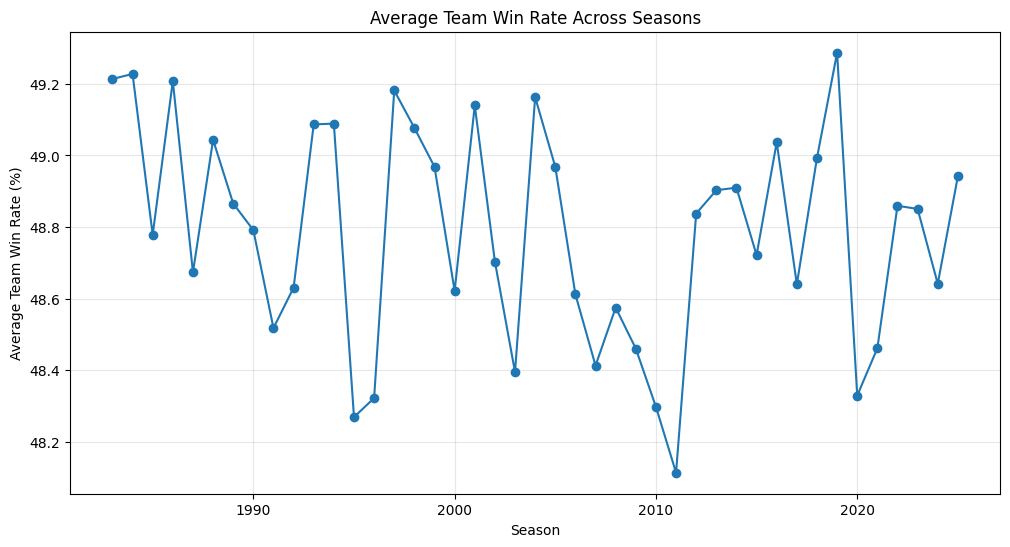

In [49]:
import matplotlib.pyplot as plt

# Average team win rate by season
season_win_rate = (
    team_win_rates
    .groupby("year")["win_rate"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    season_win_rate["year"],
    season_win_rate["win_rate"],
    marker="o"
)

plt.title("Average Team Win Rate Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Team Win Rate (%)")
plt.grid(True, alpha=0.3)

plt.show()

Team win rates vary across seasons, reflecting changes in team strength and the competitive structure of the AFL over time. Seasonal team performance is therefore a potentially useful predictor of future match outcomes.

The analysis also shows that historical team names contain formatting variations, which were handled only in an EDA copy using whitespace trimming. The original dataset was not modified.

### HOme Ground Advantage

In [50]:
# Home vs Away win rates

home_away_win_rate = (
    team_matches_eda
    .assign(
        win=(team_matches_eda["result"] == "W").astype(int)
    )
    .groupby("home_away")
    .agg(
        matches=("result", "count"),
        wins=("win", "sum"),
        win_rate=("win", "mean")
    )
    .reset_index()
)

home_away_win_rate["win_rate"] = (
    home_away_win_rate["win_rate"] * 100
).round(2)

display(home_away_win_rate)

,home_away,matches,wins,win_rate
0,A,7904,3170,40.11
1,H,7904,4669,59.07


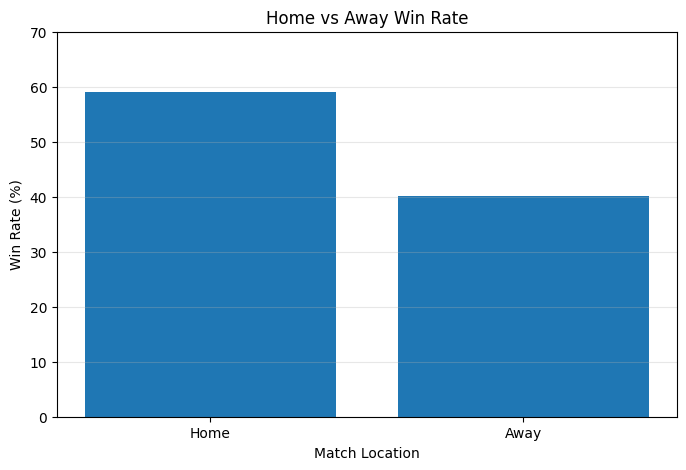

Home win rate: 59.07%
Away win rate: 40.11%
Home advantage: 18.96 percentage points


In [52]:
import matplotlib.pyplot as plt

# Explicitly get the correct values
home_win_rate = home_away_win_rate.loc[
    home_away_win_rate["home_away"] == "H", "win_rate"
].iloc[0]

away_win_rate = home_away_win_rate.loc[
    home_away_win_rate["home_away"] == "A", "win_rate"
].iloc[0]

plt.figure(figsize=(8, 5))

plt.bar(
    ["Home", "Away"],
    [home_win_rate, away_win_rate]
)

plt.title("Home vs Away Win Rate")
plt.xlabel("Match Location")
plt.ylabel("Win Rate (%)")

plt.ylim(0, 70)
plt.grid(axis="y", alpha=0.3)

plt.show()

print(f"Home win rate: {home_win_rate:.2f}%")
print(f"Away win rate: {away_win_rate:.2f}%")
print(f"Home advantage: {home_win_rate - away_win_rate:.2f} percentage points")

### Season Trends

In [53]:
# Top-performing teams by season based on win rate

top_teams_by_season = (
    team_win_rates
    .sort_values(
        ["year", "win_rate"],
        ascending=[True, False]
    )
    .groupby("year")
    .head(3)
    .reset_index(drop=True)
)

display(top_teams_by_season.head(30))

,year,team_name_eda,matches_played,wins,win_rate
0,1983,Hawthorn Hawks,25,18,72.00
1,1983,Essendon Bombers,26,18,69.23
2,1983,North Melbourne Kangaroos,24,16,66.67
3,1984,Essendon Bombers,25,20,80.00
4,1984,Hawthorn Hawks,25,19,76.00
5,1984,Collingwood Magpies,25,15,60.00
6,1985,Essendon Bombers,24,21,87.50
7,1985,W. Bulldogs,25,17,68.00
8,1985,Hawthorn Hawks,26,17,65.38
9,1986,Hawthorn Hawks,25,20,80.00


In [55]:
# Identify the highest-performing team in each season

best_team_by_season = (
    team_win_rates
    .sort_values(
        ["year", "win_rate"],
        ascending=[True, False]
    )
    .groupby("year")
    .first()
    .reset_index()
)

display(
    best_team_by_season[
        ["year", "team_name_eda", "matches_played", "wins", "win_rate"]
    ]
)

,year,team_name_eda,matches_played,wins,win_rate
0,1983,Hawthorn Hawks,25,18,72.00
1,1984,Essendon Bombers,25,20,80.00
2,1985,Essendon Bombers,24,21,87.50
3,1986,Hawthorn Hawks,25,20,80.00
4,1987,Carlton Blues,24,20,83.33
5,1988,Hawthorn Hawks,24,21,87.50
6,1989,Hawthorn Hawks,24,21,87.50
7,1990,Collingwood Magpies,26,19,73.08
8,1991,West Coast Eagles,26,21,80.77
9,1992,West Coast Eagles,25,18,72.00


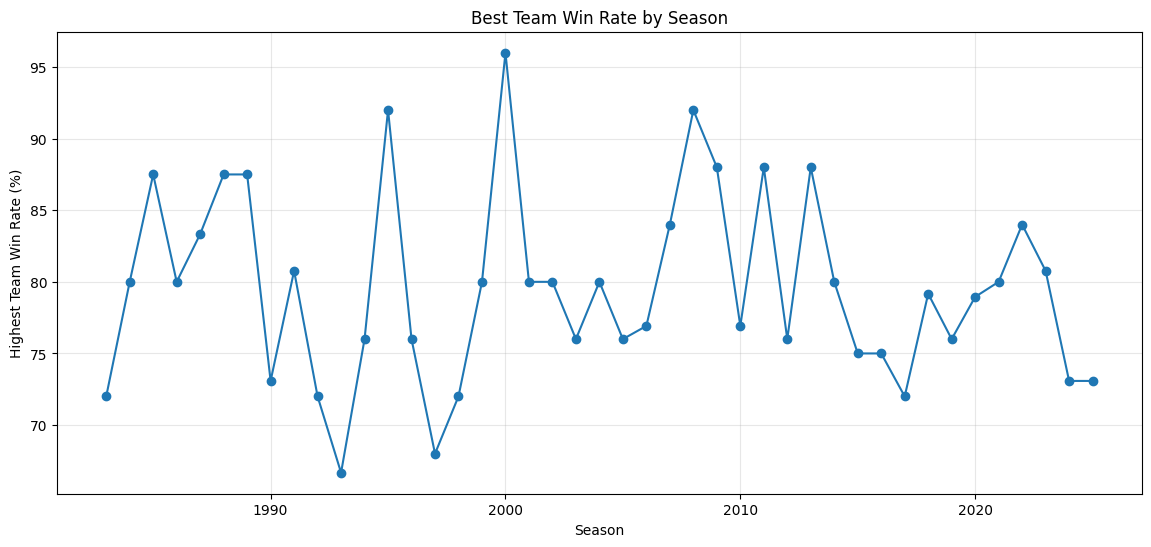

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    best_team_by_season["year"],
    best_team_by_season["win_rate"],
    marker="o"
)

plt.title("Best Team Win Rate by Season")
plt.xlabel("Season")
plt.ylabel("Highest Team Win Rate (%)")
plt.grid(True, alpha=0.3)

plt.show()

### Player-Level Performance Leaders

In [60]:
# Join player round statistics with player information
# to obtain player names.

player_eda = player_round.merge(
    player_info[["id", "player_name"]],
    left_on="player_id",
    right_on="id",
    how="left"
)

# Historical disposal statistics by player
disposal_leaders = (
    player_eda
    .groupby("player_name")
    .agg(
        matches=("disposals", "count"),
        total_disposals=("disposals", "sum"),
        average_disposals=("disposals", "mean"),
        max_disposals=("disposals", "max")
    )
    .reset_index()
    .sort_values("total_disposals", ascending=False)
)

display(disposal_leaders.head(20))

,player_name,matches,total_disposals,average_disposals,max_disposals
1088,Gary Ablett,694,17372.0,25.031700,53.0
2440,Scott Pendlebury,413,10502.0,25.428571,42.0
1589,Josh Kennedy,563,10221.0,18.154529,45.0
2306,Robert Harvey,366,9267.0,25.319672,45.0
601,Brent Harvey,414,8815.0,21.292271,44.0
243,Travis Boak,372,8620.0,23.172043,41.0
821,Craig Bradley,366,8571.0,23.418033,42.0
1502,Joel Selwood,344,8489.0,24.677326,43.0
2403,Sam Mitchell,318,8335.0,26.210692,44.0
2447,Scott West,314,8016.0,25.528662,45.0


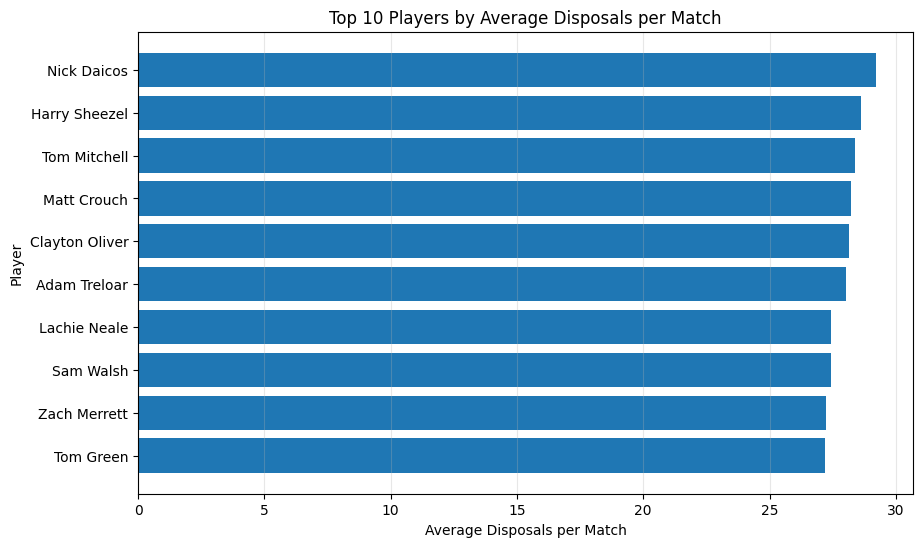

In [61]:
# Top 10 players by average disposals per match

top_disposal_average = (
    disposal_leaders
    .sort_values("average_disposals", ascending=False)
    .head(10)
    .sort_values("average_disposals")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_disposal_average["player_name"],
    top_disposal_average["average_disposals"]
)

plt.title("Top 10 Players by Average Disposals per Match")
plt.xlabel("Average Disposals per Match")
plt.ylabel("Player")

plt.grid(axis="x", alpha=0.3)

plt.show()

Historical player performance varies substantially in disposal production. While Gary Ablett has the highest total recorded disposals in the available data, players such as Lachie Neale and Sam Mitchell show very high average disposals per match.

Average disposals are more appropriate than total disposals for comparing player performance because total disposals are strongly influenced by career length and number of matches played.

In [62]:
# Historical goal-kicking statistics by player
# Missing goal values are excluded rather than treated as zero.

goal_leaders = (
    player_eda
    .dropna(subset=["goals"])
    .groupby("player_name")
    .agg(
        matches=("goals", "count"),
        total_goals=("goals", "sum"),
        average_goals=("goals", "mean"),
        max_goals=("goals", "max")
    )
    .reset_index()
    .sort_values("total_goals", ascending=False)
)

display(goal_leaders.head(20))

,player_name,matches,total_goals,average_goals,max_goals
2494,Tony Lockett,268,1360.0,5.074627,16.0
1584,Lance Franklin,354,1066.0,3.011299,13.0
1807,Matthew Lloyd,250,926.0,3.704000,13.0
1008,Gary Ablett,714,890.0,1.246499,6.0
1466,Josh Kennedy,415,880.0,2.120482,11.0
1817,Matthew Richardson,254,800.0,3.149606,10.0
2454,Tom Hawkins,354,796.0,2.248588,8.0
1146,Jack Riewoldt,347,787.0,2.268012,11.0
2235,Saverio Rocca,229,748.0,3.266376,11.0
420,Barry Hall,241,746.0,3.095436,8.0


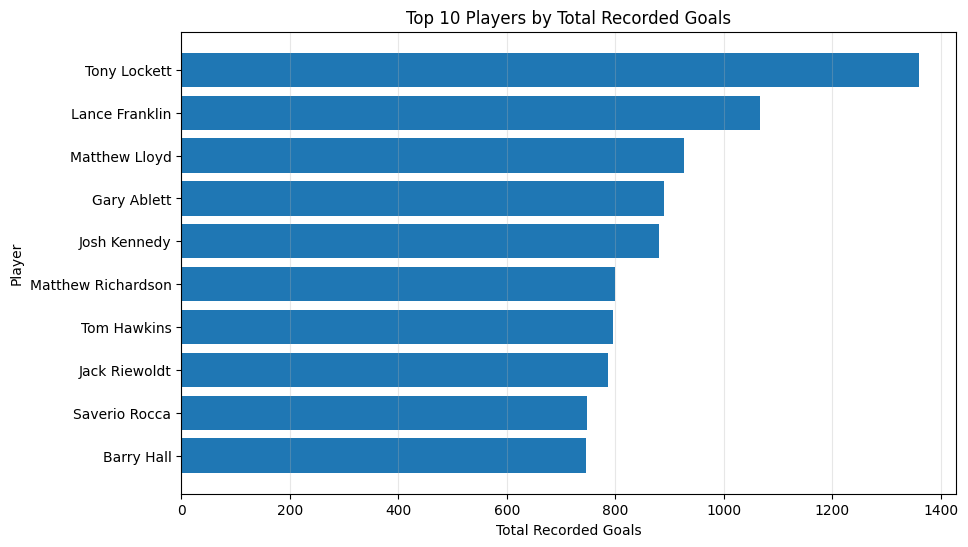

In [63]:
# Top 10 players by total recorded goals

top_goal_scorers = (
    goal_leaders
    .head(10)
    .sort_values("total_goals")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_goal_scorers["player_name"],
    top_goal_scorers["total_goals"]
)

plt.title("Top 10 Players by Total Recorded Goals")
plt.xlabel("Total Recorded Goals")
plt.ylabel("Player")

plt.grid(axis="x", alpha=0.3)

plt.show()

Goal-scoring performance varies substantially across players. Tony Lockett has the highest total recorded goals in the available player-round data, followed by Lance Franklin and Matthew Lloyd.

The analysis excludes missing goal values rather than treating them as zero because Task 1 identified substantial and historically varying missingness in the goals variable. Therefore, these results describe recorded goal performance and should be interpreted with the dataset's goal-data completeness limitation in mind.

## Relationships

### Recent Form vs Win Probability

In [64]:
# Calculate each team's recent 5-match win rate
team_form = team_matches_eda.copy()

team_form["match_date"] = pd.to_datetime(team_form["match_date"])

# Sort chronologically for each team
team_form = team_form.sort_values(
    ["team_name_eda", "match_date"]
)

# Previous 5 matches only — current match is excluded
team_form["recent_5_win_rate"] = (
    team_form
    .groupby("team_name_eda")["result"]
    .transform(
        lambda x: (
            x.eq("W")
            .shift(1)
            .rolling(5, min_periods=1)
            .mean()
        )
    )
)

# Keep matches where previous-form information exists
form_analysis = team_form.dropna(
    subset=["recent_5_win_rate"]
).copy()

form_analysis["recent_5_win_rate_pct"] = (
    form_analysis["recent_5_win_rate"] * 100
).round(2)

display(
    form_analysis[
        [
            "team_name_eda",
            "match_date",
            "recent_5_win_rate_pct",
            "result"
        ]
    ].head(20)
)

,team_name_eda,match_date,recent_5_win_rate_pct,result
13583,Adelaide Crows,1991-03-31,100.00,L
13585,Adelaide Crows,1991-04-07,50.00,W
13586,Adelaide Crows,1991-04-13,66.67,L
13587,Adelaide Crows,1991-04-21,50.00,L
13588,Adelaide Crows,1991-04-28,40.00,W
13589,Adelaide Crows,1991-05-04,40.00,L
13594,Adelaide Crows,1991-05-17,40.00,L
15785,Adelaide Crows,1991-05-24,20.00,W
13595,Adelaide Crows,1991-06-01,40.00,L
13596,Adelaide Crows,1991-06-09,40.00,W


In [65]:
# Group matches by recent-form level and calculate actual win probability
form_vs_win = (
    form_analysis
    .assign(
        win=(form_analysis["result"] == "W").astype(int)
    )
    .groupby("recent_5_win_rate_pct")
    .agg(
        matches=("win", "count"),
        wins=("win", "sum"),
        win_probability=("win", "mean")
    )
    .reset_index()
)

form_vs_win["win_probability"] = (
    form_vs_win["win_probability"] * 100
).round(2)

display(form_vs_win)

,recent_5_win_rate_pct,matches,wins,win_probability
0,0.00,1193,349,29.25
1,20.00,2656,1021,38.44
2,25.00,5,3,60.00
3,33.33,8,4,50.00
4,40.00,3994,1911,47.85
5,50.00,17,8,47.06
6,60.00,4147,2233,53.85
7,66.67,6,4,66.67
8,75.00,5,3,60.00
9,80.00,2813,1691,60.11


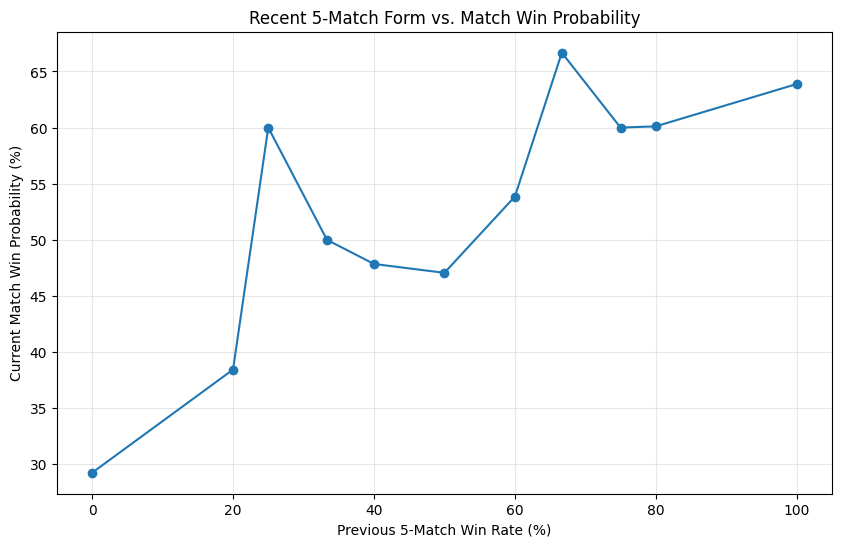

In [66]:
plt.figure(figsize=(10, 6))

plt.plot(
    form_vs_win["recent_5_win_rate_pct"],
    form_vs_win["win_probability"],
    marker="o"
)

plt.title("Recent 5-Match Form vs. Match Win Probability")
plt.xlabel("Previous 5-Match Win Rate (%)")
plt.ylabel("Current Match Win Probability (%)")
plt.grid(True, alpha=0.3)

plt.show()

Recent team form shows a generally positive relationship with the probability of winning the current match.

Teams with a previous 5-match win rate of 0% won approximately 29.25% of their subsequent matches, while teams with a 100% previous 5-match win rate won approximately 63.88% of their subsequent matches.

This indicates that recent team performance may provide useful predictive information for match outcomes. The recent-form calculation uses only matches occurring before the current match, avoiding target leakage.

Some intermediate form levels have very few observations and should therefore not be interpreted independently.

### Rest Days vs Match Outcomes

In [67]:
# Calculate rest days between consecutive matches for each team
rest_analysis = team_matches_eda.copy()

rest_analysis["match_date"] = pd.to_datetime(
    rest_analysis["match_date"]
)

rest_analysis = rest_analysis.sort_values(
    ["team_name_eda", "match_date"]
)

# Previous match date for each team
rest_analysis["previous_match_date"] = (
    rest_analysis
    .groupby("team_name_eda")["match_date"]
    .shift(1)
)

# Days since previous match
rest_analysis["rest_days"] = (
    rest_analysis["match_date"]
    - rest_analysis["previous_match_date"]
).dt.days

# Remove first match of each team's history
rest_analysis = rest_analysis.dropna(
    subset=["rest_days"]
)

display(
    rest_analysis[
        [
            "team_name_eda",
            "match_date",
            "previous_match_date",
            "rest_days",
            "result"
        ]
    ].head(20)
)

,team_name_eda,match_date,previous_match_date,rest_days,result
13583,Adelaide Crows,1991-03-31,1991-03-22,9.0,L
13585,Adelaide Crows,1991-04-07,1991-03-31,7.0,W
13586,Adelaide Crows,1991-04-13,1991-04-07,6.0,L
13587,Adelaide Crows,1991-04-21,1991-04-13,8.0,L
13588,Adelaide Crows,1991-04-28,1991-04-21,7.0,W
13589,Adelaide Crows,1991-05-04,1991-04-28,6.0,L
13594,Adelaide Crows,1991-05-17,1991-05-04,13.0,L
15785,Adelaide Crows,1991-05-24,1991-05-17,7.0,W
13595,Adelaide Crows,1991-06-01,1991-05-24,8.0,L
13596,Adelaide Crows,1991-06-09,1991-06-01,8.0,W


In [68]:
# Categorize rest periods
rest_analysis["rest_category"] = pd.cut(
    rest_analysis["rest_days"],
    bins=[-1, 5, 7, 10, float("inf")],
    labels=[
        "≤5 days",
        "6–7 days",
        "8–10 days",
        ">10 days"
    ]
)

# Calculate win rate for each rest category
rest_vs_win = (
    rest_analysis
    .assign(
        win=(rest_analysis["result"] == "W").astype(int)
    )
    .groupby("rest_category", observed=False)
    .agg(
        matches=("win", "count"),
        wins=("win", "sum"),
        win_rate=("win", "mean")
    )
    .reset_index()
)

rest_vs_win["win_rate"] = (
    rest_vs_win["win_rate"] * 100
).round(2)

display(rest_vs_win)

,rest_category,matches,wins,win_rate
0,≤5 days,402,196,48.76
1,6–7 days,9993,4933,49.36
2,8–10 days,3763,1881,49.99
3,>10 days,1630,820,50.31


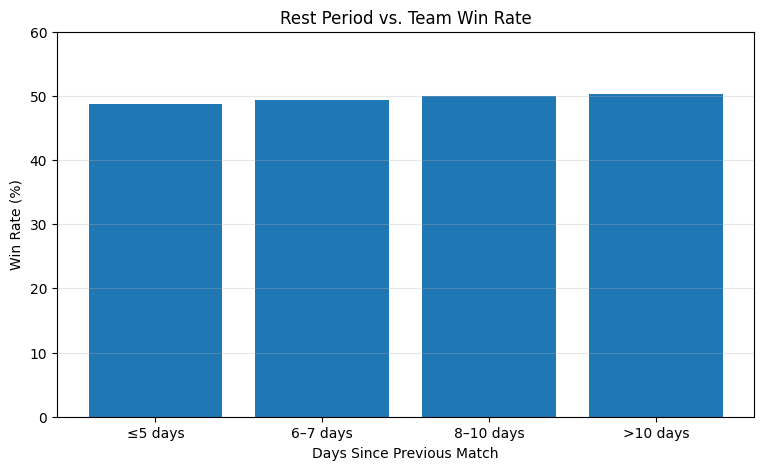

In [69]:
plt.figure(figsize=(9, 5))

plt.bar(
    rest_vs_win["rest_category"].astype(str),
    rest_vs_win["win_rate"]
)

plt.title("Rest Period vs. Team Win Rate")
plt.xlabel("Days Since Previous Match")
plt.ylabel("Win Rate (%)")
plt.ylim(0, 60)
plt.grid(axis="y", alpha=0.3)

plt.show()

The relationship between rest duration and match win rate is weak in the historical dataset.

Teams with ≤5 days of rest had a 48.76% win rate, compared with 49.36% for 6–7 days, 49.99% for 8–10 days, and 50.31% for more than 10 days.

This suggests that rest duration may provide some predictive information, but its standalone relationship with match outcome is relatively small. Rest days may be more useful when combined with other factors such as recent form, home/away status, and team strength.

### Player Disposal Consistency

In [74]:
# Calculate player disposal consistency
player_consistency = (
    player_eda
    .dropna(subset=["disposals"])
    .groupby(["player_id", "player_name"])
    .agg(
        matches=("disposals", "count"),
        average_disposals=("disposals", "mean"),
        disposal_std=("disposals", "std")
    )
    .reset_index()
)

# Keep players with enough matches for a meaningful consistency estimate
player_consistency = player_consistency[
    player_consistency["matches"] >= 20
].copy()

# Coefficient of variation
player_consistency["disposal_cv"] = (
    player_consistency["disposal_std"]
    / player_consistency["average_disposals"]
)

display(
    player_consistency
    .sort_values("average_disposals", ascending=False)
    .head(20)
)

,player_id,player_name,matches,average_disposals,disposal_std,disposal_cv
362,43668,Nick Daicos,91,29.219780,7.089589,0.242630
1440,44910,Harry Sheezel,66,28.636364,6.432218,0.224617
1097,44510,Tom Mitchell,193,28.393782,8.256334,0.290780
342,43647,Matt Crouch,161,28.229814,7.089824,0.251147
1200,44630,Clayton Oliver,197,28.131980,6.578633,0.233849
1617,45112,Adam Treloar,247,28.028340,5.964939,0.212818
1163,44585,Lachie Neale,284,27.433099,7.819006,0.285021
1665,45167,Sam Walsh,130,27.423077,5.916559,0.215751
1072,44481,Zach Merrett,245,27.232653,7.251834,0.266292
596,43936,Tom Green,113,27.203540,7.909261,0.290744


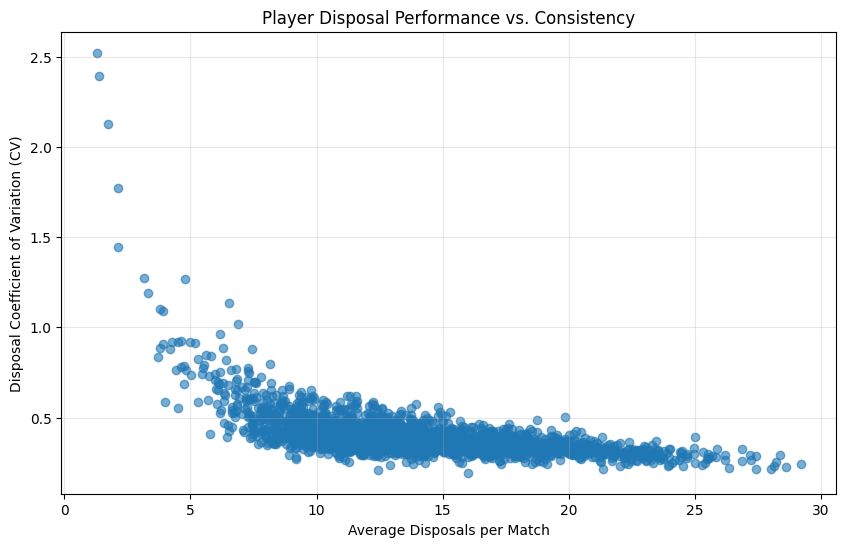

In [75]:
plt.figure(figsize=(10, 6))

plt.scatter(
    player_consistency["average_disposals"],
    player_consistency["disposal_cv"],
    alpha=0.6
)

plt.title("Player Disposal Performance vs. Consistency")
plt.xlabel("Average Disposals per Match")
plt.ylabel("Disposal Coefficient of Variation (CV)")
plt.grid(True, alpha=0.3)

plt.show()

Player disposal performance varies in both average output and consistency. Players with similar average disposal levels can have noticeably different coefficients of variation, indicating different levels of week-to-week stability.

For example, among high-disposal players, Adam Treloar has a relatively low disposal CV of approximately 0.21, while Dane Swan has a higher CV of approximately 0.33.

This suggests that both expected disposal volume and performance consistency may provide useful information when predicting the top disposal player in a match.

### Match Margine vs Team Performance

In [76]:
# Analyze relationship between match outcome and winning margin
margin_analysis = team_matches_eda.copy()

margin_analysis["absolute_margin"] = (
    margin_analysis["margin"].abs()
)

margin_summary = (
    margin_analysis
    .groupby("result")
    .agg(
        matches=("margin", "count"),
        average_margin=("absolute_margin", "mean"),
        median_margin=("absolute_margin", "median"),
        maximum_margin=("absolute_margin", "max")
    )
    .reset_index()
)

display(margin_summary)

,result,matches,average_margin,median_margin,maximum_margin
0,D,130,0.000000,0.0,0
1,L,7839,35.654675,30.0,186
2,W,7839,35.652507,30.0,186


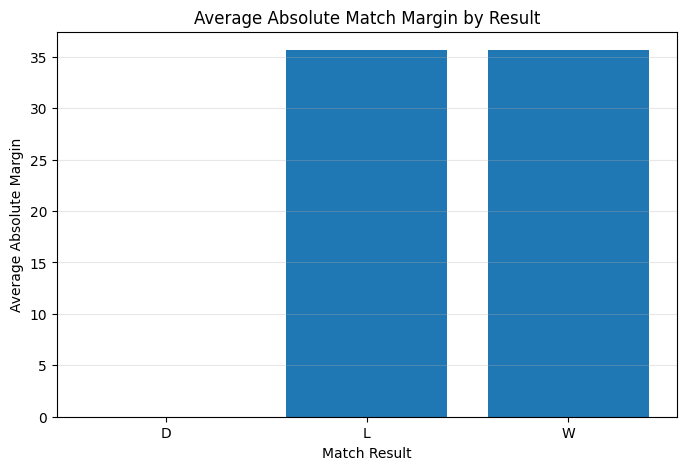

In [77]:
plt.figure(figsize=(8, 5))

plt.bar(
    margin_summary["result"],
    margin_summary["average_margin"]
)

plt.title("Average Absolute Match Margin by Result")
plt.xlabel("Match Result")
plt.ylabel("Average Absolute Margin")
plt.grid(axis="y", alpha=0.3)

plt.show()

Match margins vary substantially across AFL matches. Wins and losses are associated with different absolute margin distributions, while drawn matches have a margin of zero.

Margin is useful for understanding historical match competitiveness, but it must not be used as a feature for predicting the same match because the margin is only known after the match has been played

###Player disposals vs. fantasy points

In [78]:
# Analyze relationship between disposals and fantasy points
player_fantasy_analysis = (
    player_round[
        ["disposals", "fantasy_points"]
    ]
    .dropna()
)

print(
    "Correlation between disposals and fantasy points:",
    round(
        player_fantasy_analysis["disposals"]
        .corr(player_fantasy_analysis["fantasy_points"]),
        3
    )
)

display(
    player_fantasy_analysis.describe()
)

Correlation between disposals and fantasy points: 0.846


,disposals,fantasy_points
count,265636.000000,265636.000000
mean,15.070299,65.397085
std,7.304748,27.959707
min,-5.000000,-10.000000
25%,10.000000,46.000000
50%,14.000000,64.000000
75%,20.000000,84.000000
max,54.000000,210.000000


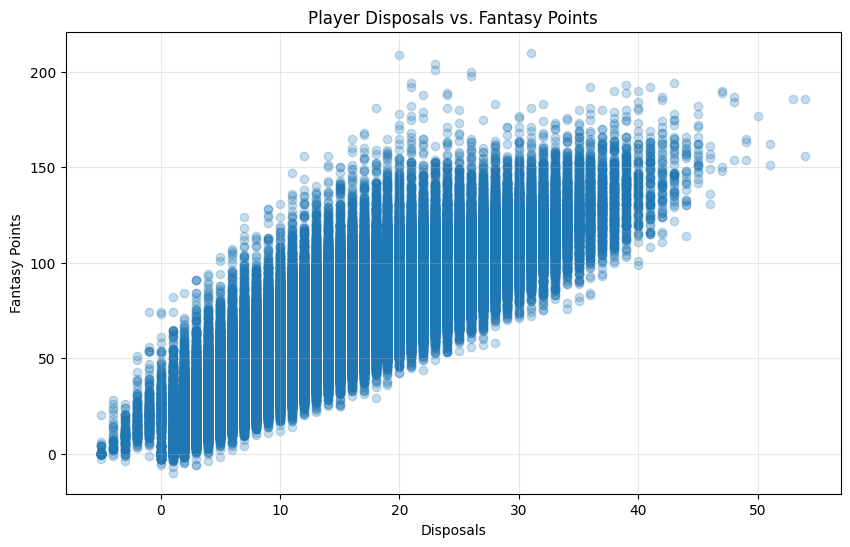

In [79]:
plt.figure(figsize=(10, 6))

plt.scatter(
    player_fantasy_analysis["disposals"],
    player_fantasy_analysis["fantasy_points"],
    alpha=0.25
)

plt.title("Player Disposals vs. Fantasy Points")
plt.xlabel("Disposals")
plt.ylabel("Fantasy Points")
plt.grid(True, alpha=0.3)

plt.show()

Player disposals show a positive relationship with fantasy points in the historical player-round data. Players producing more disposals generally tend to record higher fantasy scores, although fantasy points also depend on other performance statistics.

This relationship demonstrates that disposal volume is an important component of overall player performance and may provide useful context for player-level prediction tasks.

# **TASK 4 Feature Engineering**

In [101]:
#Prepare team-match data for match reconstruction

matches = team_matches.copy()

matches["match_date"] = pd.to_datetime(matches["match_date"])

# Standardize ONLY the formatting needed for matching.
# This does not modify the original raw dataset.
def canonical_team_name(name):
    name = str(name).strip().lower()

    aliases = {
        "w. bulldogs": "western bulldogs"
    }

    return aliases.get(name, name)

matches["team_key"] = matches["team_name"].apply(canonical_team_name)
matches["opponent_key"] = matches["opponent"].apply(canonical_team_name)

print("Total team-match rows:", len(matches))
print("Home rows:", (matches["home_away"] == "H").sum())
print("Away rows:", (matches["home_away"] == "A").sum())

display(
    matches[
        [
            "team_name",
            "team_key",
            "opponent",
            "opponent_key",
            "home_away"
        ]
    ].head()
)

Total team-match rows: 15808
Home rows: 7904
Away rows: 7904


,team_name,team_key,opponent,opponent_key,home_away
0,Hawthorn Hawks,hawthorn hawks,North Melbourne Kangaroos,north melbourne kangaroos,A
1,North Melbourne Kangaroos,north melbourne kangaroos,Hawthorn Hawks,hawthorn hawks,H
2,North Melbourne Kangaroos,north melbourne kangaroos,Brisbane Lions,brisbane lions,A
3,Sydney Swans,sydney swans,Melbourne Demons,melbourne demons,A
4,Sydney Swans,sydney swans,Geelong Cats,geelong cats,A


In [102]:
# Separate home and away records

home_matches = matches[matches["home_away"] == "H"].copy()
away_matches = matches[matches["home_away"] == "A"].copy()

# Rename columns so the two sides are explicit

home_matches = home_matches.rename(
    columns={
        "team_key": "home_team_key",
        "opponent_key": "away_team_key",
        "team_name": "home_team",
        "team_score": "home_score",
        "opponent_score": "away_score"
    }
)

away_matches = away_matches.rename(
    columns={
        "team_key": "away_team_key",
        "opponent_key": "home_team_key",
        "team_name": "away_team"
    }
)

print("Home records:", len(home_matches))
print("Away records:", len(away_matches))

Home records: 7904
Away records: 7904


In [103]:
# Reconstruct one row per actual AFL match

reconstructed_matches = home_matches.merge(
    away_matches[
        [
            "match_date",
            "round",
            "home_team_key",
            "away_team_key",
            "team_score",
            "opponent_score"
        ]
    ].rename(
        columns={
            "team_score": "away_team_score_check",
            "opponent_score": "home_team_score_check"
        }
    ),
    on=[
        "match_date",
        "round",
        "home_team_key",
        "away_team_key"
    ],
    how="left"
)

print("Reconstructed matches:", len(reconstructed_matches))
print(
    "Matches with no reciprocal away record:",
    reconstructed_matches["away_team_score_check"].isna().sum()
)

Reconstructed matches: 7904
Matches with no reciprocal away record: 0


In [109]:
# Verify that the home and away records describe the same match

reconstructed_matches["score_match"] = (
    (reconstructed_matches["home_score"] ==
     reconstructed_matches["home_team_score_check"])
    &
    (reconstructed_matches["away_score"] ==
     reconstructed_matches["away_team_score_check"])
)

print("Total reconstructed matches:", len(reconstructed_matches))
print(
    "Score matches:",
    reconstructed_matches["score_match"].sum()
)
print(
    "Score mismatches:",
    (~reconstructed_matches["score_match"]).sum()
)



Total reconstructed matches: 7904
Score matches: 7904
Score mismatches: 0


In [111]:
#Create clean match-level base table
import numpy as np

match_base = reconstructed_matches[
    [
        "match_date",
        "round",
        "year",
        "home_team",
        "home_team_key",
        "away_team_key",
        "home_score",
        "away_score",
        "venue",
        "crowd"
    ]
].copy()

# Convert team keys to readable canonical names
# while keeping historical team identities separate.
match_base["home_team"] = (
    match_base["home_team_key"]
    .str.title()
)

match_base["away_team"] = (
    match_base["away_team_key"]
    .str.title()
)

# Create the target
match_base["match_winner"] = np.select(
    [
        match_base["home_score"] > match_base["away_score"],
        match_base["home_score"] < match_base["away_score"]
    ],
    [
        "Home Win",
        "Away Win"
    ],
    default="Draw"
)

# Sort chronologically
match_base = match_base.sort_values(
    ["match_date", "round"]
).reset_index(drop=True)

print("Match-level rows:", len(match_base))
print("\nTarget distribution:")
display(
    match_base["match_winner"]
    .value_counts()
    .to_frame("matches")
)

print("\nFirst 5 matches:")
display(match_base.head())

Match-level rows: 7904

Target distribution:


,matches
match_winner,
Home Win,4669
Away Win,3170
Draw,65



First 5 matches:


,match_date,round,year,home_team,home_team_key,away_team_key,home_score,away_score,venue,crowd,away_team,match_winner
0,1983-03-26,1,1983,Carlton Blues,carlton blues,richmond tigers,136,76,Princes Park,28498.0,Richmond Tigers,Home Win
1,1983-03-26,1,1983,Geelong Cats,geelong cats,western bulldogs,106,75,Waverley Park,18377.0,Western Bulldogs,Home Win
2,1983-03-26,1,1983,Melbourne Demons,melbourne demons,collingwood magpies,125,135,Melbourne Cricket Ground,72274.0,Collingwood Magpies,Away Win
3,1983-03-26,1,1983,Fitzroy Lions,fitzroy lions,hawthorn hawks,112,131,Junction Oval,15626.0,Hawthorn Hawks,Away Win
4,1983-03-26,1,1983,North Melbourne Kangaroos,north melbourne kangaroos,st kilda saints,100,87,Aegis Park,18496.0,St Kilda Saints,Home Win


In [112]:
#Create chronological team history

# Create one row for each team's participation in each match.
# This allows us to calculate historical team features.

home_history = match_base[
    [
        "match_date",
        "round",
        "year",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "venue",
        "match_winner"
    ]
].copy()

home_history["team"] = home_history["home_team"]
home_history["opponent"] = home_history["away_team"]
home_history["team_score"] = home_history["home_score"]
home_history["opponent_score"] = home_history["away_score"]
home_history["result"] = np.select(
    [
        home_history["home_score"] > home_history["away_score"],
        home_history["home_score"] < home_history["away_score"]
    ],
    ["W", "L"],
    default="D"
)

away_history = match_base[
    [
        "match_date",
        "round",
        "year",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "venue",
        "match_winner"
    ]
].copy()

away_history["team"] = away_history["away_team"]
away_history["opponent"] = away_history["home_team"]
away_history["team_score"] = away_history["away_score"]
away_history["opponent_score"] = away_history["home_score"]
away_history["result"] = np.select(
    [
        away_history["away_score"] > away_history["home_score"],
        away_history["away_score"] < away_history["home_score"]
    ],
    ["W", "L"],
    default="D"
)

team_history = pd.concat(
    [home_history, away_history],
    ignore_index=True
)

team_history = team_history.sort_values(
    ["team", "match_date", "round"]
).reset_index(drop=True)

print("Team-match history rows:", len(team_history))
print("\nExpected:", len(match_base) * 2)

display(
    team_history[
        [
            "match_date",
            "round",
            "team",
            "opponent",
            "team_score",
            "opponent_score",
            "result"
        ]
    ].head(10)
)

Team-match history rows: 15808

Expected: 15808


,match_date,round,team,opponent,team_score,opponent_score,result
0,1991-03-22,1,Adelaide Crows,Hawthorn Hawks,155,69,W
1,1991-03-31,2,Adelaide Crows,Carlton Blues,81,104,L
2,1991-04-07,3,Adelaide Crows,Sydney Swans,132,108,W
3,1991-04-13,4,Adelaide Crows,Essendon Bombers,47,92,L
4,1991-04-21,5,Adelaide Crows,West Coast Eagles,65,130,L
5,1991-04-28,6,Adelaide Crows,Western Bulldogs,128,97,W
6,1991-05-04,7,Adelaide Crows,St Kilda Saints,31,162,L
7,1991-05-17,9,Adelaide Crows,North Melbourne Kangaroos,118,120,L
8,1991-05-24,10,Adelaide Crows,Melbourne Demons,106,72,W
9,1991-06-01,11,Adelaide Crows,Geelong Cats,93,177,L


In [113]:
# previous 5-game win rate

team_history["win"] = (
    team_history["result"] == "W"
).astype(int)

team_history["recent_5_win_rate"] = (
    team_history
    .groupby("team")["win"]
    .transform(
        lambda x: (
            x.shift(1)
             .rolling(window=5, min_periods=1)
             .mean()
        )
    )
)

team_history["recent_5_win_rate_pct"] = (
    team_history["recent_5_win_rate"] * 100
).round(2)

display(
    team_history[
        [
            "match_date",
            "round",
            "team",
            "opponent",
            "result",
            "recent_5_win_rate_pct"
        ]
    ].head(15)
)

,match_date,round,team,opponent,result,recent_5_win_rate_pct
0,1991-03-22,1,Adelaide Crows,Hawthorn Hawks,W,NaN
1,1991-03-31,2,Adelaide Crows,Carlton Blues,L,100.00
2,1991-04-07,3,Adelaide Crows,Sydney Swans,W,50.00
3,1991-04-13,4,Adelaide Crows,Essendon Bombers,L,66.67
4,1991-04-21,5,Adelaide Crows,West Coast Eagles,L,50.00
5,1991-04-28,6,Adelaide Crows,Western Bulldogs,W,40.00
6,1991-05-04,7,Adelaide Crows,St Kilda Saints,L,40.00
7,1991-05-17,9,Adelaide Crows,North Melbourne Kangaroos,L,40.00
8,1991-05-24,10,Adelaide Crows,Melbourne Demons,W,20.00
9,1991-06-01,11,Adelaide Crows,Geelong Cats,L,40.00


In [114]:
# Verify that the current match result is NOT being used

adelaide_check = team_history[
    team_history["team"] == "Adelaide Crows"
].copy()

display(
    adelaide_check[
        [
            "match_date",
            "round",
            "result",
            "recent_5_win_rate_pct"
        ]
    ].head(10)
)

,match_date,round,result,recent_5_win_rate_pct
0,1991-03-22,1,W,NaN
1,1991-03-31,2,L,100.00
2,1991-04-07,3,W,50.00
3,1991-04-13,4,L,66.67
4,1991-04-21,5,L,50.00
5,1991-04-28,6,W,40.00
6,1991-05-04,7,L,40.00
7,1991-05-17,9,L,40.00
8,1991-05-24,10,W,20.00
9,1991-06-01,11,L,40.00


### Team Win Streak

In [116]:
# Task 4.6 — Correct leakage-safe team win streak

def add_win_streak(group):
    results = group["result"].tolist()

    streaks = []
    streak = 0

    for result in results:
        # Streak entering the current match
        streaks.append(streak)

        if result == "W":
            streak += 1
        else:
            streak = 0

    group = group.copy()
    group["win_streak"] = streaks

    return group


team_history = (
    team_history
    .groupby("team", group_keys=False)
    .apply(add_win_streak)
    .reset_index(drop=True)
)

display(
    team_history[
        [
            "match_date",
            "round",
            "team",
            "opponent",
            "result",
            "win_streak"
        ]
    ].head(15)
)

/tmp/ipykernel_7668/3351286531.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_win_streak)


,match_date,round,team,opponent,result,win_streak
0,1991-03-22,1,Adelaide Crows,Hawthorn Hawks,W,0
1,1991-03-31,2,Adelaide Crows,Carlton Blues,L,1
2,1991-04-07,3,Adelaide Crows,Sydney Swans,W,0
3,1991-04-13,4,Adelaide Crows,Essendon Bombers,L,1
4,1991-04-21,5,Adelaide Crows,West Coast Eagles,L,0
5,1991-04-28,6,Adelaide Crows,Western Bulldogs,W,0
6,1991-05-04,7,Adelaide Crows,St Kilda Saints,L,1
7,1991-05-17,9,Adelaide Crows,North Melbourne Kangaroos,L,0
8,1991-05-24,10,Adelaide Crows,Melbourne Demons,W,0
9,1991-06-01,11,Adelaide Crows,Geelong Cats,L,1


### Last 5 Games Avg Score

In [117]:
# Task 4.7 — Leakage-safe previous 5-game average score

team_history["recent_5_avg_score"] = (
    team_history
    .groupby("team")["team_score"]
    .transform(
        lambda x: (
            x.shift(1)
             .rolling(window=5, min_periods=1)
             .mean()
        )
    )
)

team_history["recent_5_avg_score"] = (
    team_history["recent_5_avg_score"]
    .round(2)
)

display(
    team_history[
        [
            "match_date",
            "round",
            "team",
            "opponent",
            "team_score",
            "recent_5_avg_score"
        ]
    ].head(15)
)

,match_date,round,team,opponent,team_score,recent_5_avg_score
0,1991-03-22,1,Adelaide Crows,Hawthorn Hawks,155,NaN
1,1991-03-31,2,Adelaide Crows,Carlton Blues,81,155.00
2,1991-04-07,3,Adelaide Crows,Sydney Swans,132,118.00
3,1991-04-13,4,Adelaide Crows,Essendon Bombers,47,122.67
4,1991-04-21,5,Adelaide Crows,West Coast Eagles,65,103.75
5,1991-04-28,6,Adelaide Crows,Western Bulldogs,128,96.00
6,1991-05-04,7,Adelaide Crows,St Kilda Saints,31,90.60
7,1991-05-17,9,Adelaide Crows,North Melbourne Kangaroos,118,80.60
8,1991-05-24,10,Adelaide Crows,Melbourne Demons,106,77.80
9,1991-06-01,11,Adelaide Crows,Geelong Cats,93,89.60


In [118]:
adelaide_score_check = team_history[
    team_history["team"] == "Adelaide Crows"
][
    [
        "match_date",
        "round",
        "team_score",
        "recent_5_avg_score"
    ]
].head(8)

display(adelaide_score_check)

,match_date,round,team_score,recent_5_avg_score
0,1991-03-22,1,155,NaN
1,1991-03-31,2,81,155.00
2,1991-04-07,3,132,118.00
3,1991-04-13,4,47,122.67
4,1991-04-21,5,65,103.75
5,1991-04-28,6,128,96.00
6,1991-05-04,7,31,90.60
7,1991-05-17,9,118,80.60


### Last 5 games player output

In [119]:
# Prepare chronological player history

player_history = player_round.copy()

player_history["match_date"] = pd.to_datetime(
    player_history["match_date"]
)

# Standardize team names only for joining.
player_history["team_key"] = (
    player_history["team"]
    .astype(str)
    .str.strip()
    .str.lower()
)

player_history = player_history.sort_values(
    ["player_id", "match_date", "round"]
).reset_index(drop=True)

print("Player-game rows:", len(player_history))

display(
    player_history[
        [
            "player_id",
            "team",
            "match_date",
            "round",
            "disposals"
        ]
    ].head(10)
)

Player-game rows: 274089


,player_id,team,match_date,round,disposals
0,43260,Richmond Tigers,2020-07-05,5,16.0
1,43260,Richmond Tigers,2020-07-12,6,6.0
2,43260,Richmond Tigers,2020-07-18,7,8.0
3,43260,Richmond Tigers,2020-07-24,8,5.0
4,43260,Richmond Tigers,2020-07-29,9,7.0
5,43260,Richmond Tigers,2020-08-04,10,14.0
6,43260,Richmond Tigers,2020-08-08,11,10.0
7,43260,Richmond Tigers,2020-08-17,12,4.0
8,43260,Richmond Tigers,2020-08-22,13,10.0
9,43260,Richmond Tigers,2020-08-27,14,16.0


In [120]:
# previous 5-game average disposals for each player

player_history["player_recent_5_avg_disposals"] = (
    player_history
    .groupby("player_id")["disposals"]
    .transform(
        lambda x: (
            x.shift(1)
             .rolling(window=5, min_periods=1)
             .mean()
        )
    )
)

player_history["player_recent_5_avg_disposals"] = (
    player_history["player_recent_5_avg_disposals"]
    .round(2)
)

display(
    player_history[
        [
            "player_id",
            "team",
            "match_date",
            "round",
            "disposals",
            "player_recent_5_avg_disposals"
        ]
    ].head(15)
)

,player_id,team,match_date,round,disposals,player_recent_5_avg_disposals
0,43260,Richmond Tigers,2020-07-05,5,16.0,NaN
1,43260,Richmond Tigers,2020-07-12,6,6.0,16.00
2,43260,Richmond Tigers,2020-07-18,7,8.0,11.00
3,43260,Richmond Tigers,2020-07-24,8,5.0,10.00
4,43260,Richmond Tigers,2020-07-29,9,7.0,8.75
5,43260,Richmond Tigers,2020-08-04,10,14.0,8.40
6,43260,Richmond Tigers,2020-08-08,11,10.0,8.00
7,43260,Richmond Tigers,2020-08-17,12,4.0,8.80
8,43260,Richmond Tigers,2020-08-22,13,10.0,8.00
9,43260,Richmond Tigers,2020-08-27,14,16.0,9.00


### Head to Head Historical Record

In [122]:
# H2H features from the current home team's perspective

h2h = match_base[
    [
        "match_date",
        "round",
        "home_team",
        "away_team",
        "match_winner"
    ]
].copy()

# Create an unordered matchup key
h2h["team_1"] = h2h[["home_team", "away_team"]].min(axis=1)
h2h["team_2"] = h2h[["home_team", "away_team"]].max(axis=1)

h2h["matchup_key"] = (
    h2h["team_1"] + "||" + h2h["team_2"]
)

# Sort chronologically within each matchup
h2h = h2h.sort_values(
    ["matchup_key", "match_date", "round"]
).reset_index(drop=True)

# Determine the result from the perspective of each team

h2h["home_team_won"] = (
    h2h["match_winner"] == "Home Win"
).astype(int)

h2h["away_team_won"] = (
    h2h["match_winner"] == "Away Win"
).astype(int)

h2h["draw"] = (
    h2h["match_winner"] == "Draw"
).astype(int)


# Historical results BEFORE the current match


h2h["previous_home_team_wins"] = (
    h2h.groupby("matchup_key")["home_team_won"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

h2h["previous_away_team_wins"] = (
    h2h.groupby("matchup_key")["away_team_won"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

h2h["previous_draws"] = (
    h2h.groupby("matchup_key")["draw"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

# Total previous meetings
h2h["h2h_matches"] = (
    h2h["previous_home_team_wins"]
    + h2h["previous_away_team_wins"]
    + h2h["previous_draws"]
)

# Convert historical results to CURRENT home team's
# perspective

h2h["h2h_current_home_wins"] = np.where(
    h2h["home_team"] == h2h["team_1"],
    h2h["previous_home_team_wins"],
    h2h["previous_away_team_wins"]
)

h2h["h2h_current_away_wins"] = np.where(
    h2h["away_team"] == h2h["team_1"],
    h2h["previous_home_team_wins"],
    h2h["previous_away_team_wins"]
)

h2h["h2h_draws"] = h2h["previous_draws"]

# Current home team's historical win rate
h2h["h2h_current_home_win_rate"] = np.where(
    h2h["h2h_matches"] > 0,
    h2h["h2h_current_home_wins"] / h2h["h2h_matches"],
    np.nan
)

h2h["h2h_current_home_win_rate"] = (
    h2h["h2h_current_home_win_rate"] * 100
).round(2)

# Final H2H table
h2h_features = h2h[
    [
        "match_date",
        "round",
        "home_team",
        "away_team",
        "match_winner",
        "h2h_matches",
        "h2h_current_home_wins",
        "h2h_current_away_wins",
        "h2h_draws",
        "h2h_current_home_win_rate"
    ]
].copy()

display(h2h_features.head(15))

,match_date,round,home_team,away_team,match_winner,h2h_matches,h2h_current_home_wins,h2h_current_away_wins,h2h_draws,h2h_current_home_win_rate
0,1991-06-23,14,Adelaide Crows,Brisbane Bears,Home Win,0.0,0.0,0.0,0.0,NaN
1,1992-04-26,6,Adelaide Crows,Brisbane Bears,Home Win,1.0,1.0,0.0,0.0,100.00
2,1992-08-09,21,Brisbane Bears,Adelaide Crows,Away Win,2.0,0.0,2.0,0.0,0.00
3,1993-05-30,10,Brisbane Bears,Adelaide Crows,Away Win,3.0,1.0,2.0,0.0,33.33
4,1994-04-30,6,Brisbane Bears,Adelaide Crows,Away Win,4.0,2.0,2.0,0.0,50.00
5,1994-08-14,21,Adelaide Crows,Brisbane Bears,Home Win,5.0,2.0,3.0,0.0,40.00
6,1995-04-09,2,Brisbane Bears,Adelaide Crows,Home Win,6.0,3.0,3.0,0.0,50.00
7,1995-07-30,17,Adelaide Crows,Brisbane Bears,Away Win,7.0,4.0,3.0,0.0,57.14
8,1996-07-06,14,Adelaide Crows,Brisbane Bears,Home Win,8.0,4.0,4.0,0.0,50.00
9,1997-03-30,1,Adelaide Crows,Brisbane Lions,Home Win,0.0,0.0,0.0,0.0,NaN


### Days of Rest

In [123]:
# days of rest

team_history["previous_match_date"] = (
    team_history
    .groupby("team")["match_date"]
    .shift(1)
)

team_history["days_rest"] = (
    team_history["match_date"]
    - team_history["previous_match_date"]
).dt.days

# Display examples
display(
    team_history[
        [
            "match_date",
            "team",
            "previous_match_date",
            "days_rest"
        ]
    ].head(20)
)

,match_date,team,previous_match_date,days_rest
0,1991-03-22,Adelaide Crows,NaT,NaN
1,1991-03-31,Adelaide Crows,1991-03-22,9.0
2,1991-04-07,Adelaide Crows,1991-03-31,7.0
3,1991-04-13,Adelaide Crows,1991-04-07,6.0
4,1991-04-21,Adelaide Crows,1991-04-13,8.0
5,1991-04-28,Adelaide Crows,1991-04-21,7.0
6,1991-05-04,Adelaide Crows,1991-04-28,6.0
7,1991-05-17,Adelaide Crows,1991-05-04,13.0
8,1991-05-24,Adelaide Crows,1991-05-17,7.0
9,1991-06-01,Adelaide Crows,1991-05-24,8.0


### Pre Match Ladder Position

In [124]:
# Prepare historical standings information

ladder_history = team_history.copy()

# Premiership points from each completed match
ladder_history["ladder_points"] = np.select(
    [
        ladder_history["result"] == "W",
        ladder_history["result"] == "D",
        ladder_history["result"] == "L"
    ],
    [
        4,
        2,
        0
    ],
    default=np.nan
)

# Win indicator
ladder_history["ladder_win"] = (
    ladder_history["result"] == "W"
).astype(int)

# Draw indicator
ladder_history["ladder_draw"] = (
    ladder_history["result"] == "D"
).astype(int)

# Score for / against
ladder_history["score_for"] = ladder_history["team_score"]
ladder_history["score_against"] = ladder_history["opponent_score"]

# Sort chronologically within each team and season
ladder_history = ladder_history.sort_values(
    ["year", "team", "match_date", "round"]
).reset_index(drop=True)

# Cumulative standings BEFORE the current match
ladder_history["pre_match_points"] = (
    ladder_history
    .groupby(["year", "team"])["ladder_points"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

ladder_history["pre_match_wins"] = (
    ladder_history
    .groupby(["year", "team"])["ladder_win"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

ladder_history["pre_match_draws"] = (
    ladder_history
    .groupby(["year", "team"])["ladder_draw"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

ladder_history["pre_match_score_for"] = (
    ladder_history
    .groupby(["year", "team"])["score_for"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

ladder_history["pre_match_score_against"] = (
    ladder_history
    .groupby(["year", "team"])["score_against"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

# Percentage based on results before the current match
ladder_history["pre_match_percentage"] = np.where(
    ladder_history["pre_match_score_against"] > 0,
    (
        ladder_history["pre_match_score_for"]
        / ladder_history["pre_match_score_against"]
    ) * 100,
    np.nan
)

ladder_history["pre_match_percentage"] = (
    ladder_history["pre_match_percentage"].round(2)
)

display(
    ladder_history[
        [
            "year",
            "match_date",
            "team",
            "result",
            "pre_match_points",
            "pre_match_wins",
            "pre_match_draws",
            "pre_match_score_for",
            "pre_match_score_against",
            "pre_match_percentage"
        ]
    ].head(20)
)

,year,match_date,team,result,pre_match_points,pre_match_wins,pre_match_draws,pre_match_score_for,pre_match_score_against,pre_match_percentage
0,1983,1983-03-26,Carlton Blues,W,0.0,0.0,0.0,0.0,0.0,NaN
1,1983,1983-04-02,Carlton Blues,L,4.0,1.0,0.0,136.0,76.0,178.95
2,1983,1983-04-09,Carlton Blues,W,4.0,1.0,0.0,218.0,175.0,124.57
3,1983,1983-04-16,Carlton Blues,W,8.0,2.0,0.0,315.0,262.0,120.23
4,1983,1983-04-23,Carlton Blues,L,12.0,3.0,0.0,414.0,352.0,117.61
5,1983,1983-04-30,Carlton Blues,L,12.0,3.0,0.0,479.0,477.0,100.42
6,1983,1983-05-08,Carlton Blues,W,12.0,3.0,0.0,564.0,572.0,98.60
7,1983,1983-05-14,Carlton Blues,W,16.0,4.0,0.0,713.0,690.0,103.33
8,1983,1983-05-21,Carlton Blues,W,20.0,5.0,0.0,858.0,779.0,110.14
9,1983,1983-05-28,Carlton Blues,L,24.0,6.0,0.0,962.0,875.0,109.94


In [125]:
#Calculate reconstructed pre-match ladder rank

# Replace undefined percentage with 0 for ranking purposes.
# This only affects teams with no previous score conceded.
ladder_history["ranking_percentage"] = (
    ladder_history["pre_match_percentage"]
    .fillna(0)
)

# Rank teams within each season and match date.
# Lower rank number = better ladder position.
ladder_history["pre_match_ladder_rank"] = (
    ladder_history
    .groupby(["year", "match_date"])[
        [
            "pre_match_points",
            "ranking_percentage",
            "pre_match_wins"
        ]
    ]
    .rank(
        method="min",
        ascending=False
    )["pre_match_points"]
)

# Convert to integer where possible
ladder_history["pre_match_ladder_rank"] = (
    ladder_history["pre_match_ladder_rank"]
    .astype(int)
)

display(
    ladder_history[
        [
            "year",
            "match_date",
            "team",
            "pre_match_points",
            "pre_match_percentage",
            "pre_match_wins",
            "pre_match_ladder_rank"
        ]
    ].head(20)
)

,year,match_date,team,pre_match_points,pre_match_percentage,pre_match_wins,pre_match_ladder_rank
0,1983,1983-03-26,Carlton Blues,0.0,NaN,0.0,1
1,1983,1983-04-02,Carlton Blues,4.0,178.95,1.0,1
2,1983,1983-04-09,Carlton Blues,4.0,124.57,1.0,3
3,1983,1983-04-16,Carlton Blues,8.0,120.23,2.0,3
4,1983,1983-04-23,Carlton Blues,12.0,117.61,3.0,1
5,1983,1983-04-30,Carlton Blues,12.0,100.42,3.0,5
6,1983,1983-05-08,Carlton Blues,12.0,98.60,3.0,1
7,1983,1983-05-14,Carlton Blues,16.0,103.33,4.0,4
8,1983,1983-05-21,Carlton Blues,20.0,110.14,5.0,2
9,1983,1983-05-28,Carlton Blues,24.0,109.94,6.0,2


In [126]:
# Attach pre-match ladder rank to each match

ladder_features = ladder_history[
    [
        "match_date",
        "round",
        "team",
        "pre_match_ladder_rank",
        "pre_match_points",
        "pre_match_percentage"
    ]
].copy()

# Home team ladder information
home_ladder = ladder_features.rename(
    columns={
        "team": "home_team",
        "pre_match_ladder_rank": "home_pre_match_ladder_rank",
        "pre_match_points": "home_pre_match_points",
        "pre_match_percentage": "home_pre_match_percentage"
    }
)

# Away team ladder information
away_ladder = ladder_features.rename(
    columns={
        "team": "away_team",
        "pre_match_ladder_rank": "away_pre_match_ladder_rank",
        "pre_match_points": "away_pre_match_points",
        "pre_match_percentage": "away_pre_match_percentage"
    }
)

# Merge both sides
match_ladder_features = (
    match_base[
        [
            "match_date",
            "round",
            "home_team",
            "away_team"
        ]
    ]
    .merge(
        home_ladder,
        on=["match_date", "round", "home_team"],
        how="left"
    )
    .merge(
        away_ladder,
        on=["match_date", "round", "away_team"],
        how="left"
    )
)

display(match_ladder_features.head(20))

,match_date,round,home_team,away_team,home_pre_match_ladder_rank,home_pre_match_points,home_pre_match_percentage,away_pre_match_ladder_rank,away_pre_match_points,away_pre_match_percentage
0,1983-03-26,1,Carlton Blues,Richmond Tigers,1,0.0,NaN,1,0.0,NaN
1,1983-03-26,1,Geelong Cats,Western Bulldogs,1,0.0,NaN,1,0.0,NaN
2,1983-03-26,1,Melbourne Demons,Collingwood Magpies,1,0.0,NaN,1,0.0,NaN
3,1983-03-26,1,Fitzroy Lions,Hawthorn Hawks,1,0.0,NaN,1,0.0,NaN
4,1983-03-26,1,North Melbourne Kangaroos,St Kilda Saints,1,0.0,NaN,1,0.0,NaN
5,1983-03-27,1,Sydney Swans,Essendon Bombers,1,0.0,NaN,1,0.0,NaN
6,1983-04-02,2,Collingwood Magpies,Geelong Cats,1,4.0,108.00,1,4.0,141.33
7,1983-04-02,2,Richmond Tigers,Melbourne Demons,4,0.0,55.88,4,0.0,92.59
8,1983-04-02,2,Western Bulldogs,Carlton Blues,4,0.0,70.75,1,4.0,178.95
9,1983-04-04,2,Essendon Bombers,St Kilda Saints,4,0.0,99.10,4,0.0,87.00


### Final Match Feature Table

In [127]:
#Assemble match level features

# HOME TEAM FEATURES

home_team_features = team_history[
    [
        "match_date",
        "round",
        "team",
        "recent_5_win_rate",
        "win_streak",
        "recent_5_avg_score",
        "days_rest"
    ]
].rename(
    columns={
        "team": "home_team",
        "recent_5_win_rate": "home_recent_5_win_rate",
        "win_streak": "home_win_streak",
        "recent_5_avg_score": "home_recent_5_avg_score",
        "days_rest": "home_days_rest"
    }
)

# AWAY TEAM FEATURES

away_team_features = team_history[
    [
        "match_date",
        "round",
        "team",
        "recent_5_win_rate",
        "win_streak",
        "recent_5_avg_score",
        "days_rest"
    ]
].rename(
    columns={
        "team": "away_team",
        "recent_5_win_rate": "away_recent_5_win_rate",
        "win_streak": "away_win_streak",
        "recent_5_avg_score": "away_recent_5_avg_score",
        "days_rest": "away_days_rest"
    }
)

# START WITH MATCH INFORMATION

afl_match_features_v1 = match_base[
    [
        "match_date",
        "round",
        "year",
        "home_team",
        "away_team",
        "venue",
        "match_winner"
    ]
].copy()

# MERGE TEAM FORM FEATURES

afl_match_features_v1 = (
    afl_match_features_v1
    .merge(
        home_team_features,
        on=["match_date", "round", "home_team"],
        how="left"
    )
    .merge(
        away_team_features,
        on=["match_date", "round", "away_team"],
        how="left"
    )
)

# MERGE H2H FEATURES

afl_match_features_v1 = (
    afl_match_features_v1
    .merge(
        h2h_features[
            [
                "match_date",
                "round",
                "home_team",
                "away_team",
                "h2h_matches",
                "h2h_current_home_wins",
                "h2h_current_away_wins",
                "h2h_draws",
                "h2h_current_home_win_rate"
            ]
        ],
        on=[
            "match_date",
            "round",
            "home_team",
            "away_team"
        ],
        how="left"
    )
)

# MERGE LADDER FEATURES

afl_match_features_v1 = (
    afl_match_features_v1
    .merge(
        match_ladder_features[
            [
                "match_date",
                "round",
                "home_team",
                "away_team",
                "home_pre_match_ladder_rank",
                "home_pre_match_points",
                "home_pre_match_percentage",
                "away_pre_match_ladder_rank",
                "away_pre_match_points",
                "away_pre_match_percentage"
            ]
        ],
        on=[
            "match_date",
            "round",
            "home_team",
            "away_team"
        ],
        how="left"
    )
)

# CHECK RESULT

print("Rows:", len(afl_match_features_v1))
print("Columns:", len(afl_match_features_v1.columns))

display(afl_match_features_v1.head(10))

Rows: 7904
Columns: 26


,match_date,round,year,home_team,away_team,venue,match_winner,home_recent_5_win_rate,home_win_streak,home_recent_5_avg_score,...,h2h_current_home_wins,h2h_current_away_wins,h2h_draws,h2h_current_home_win_rate,home_pre_match_ladder_rank,home_pre_match_points,home_pre_match_percentage,away_pre_match_ladder_rank,away_pre_match_points,away_pre_match_percentage
0,1983-03-26,1,1983,Carlton Blues,Richmond Tigers,Princes Park,Home Win,NaN,0,NaN,...,0.0,0.0,0.0,NaN,1,0.0,NaN,1,0.0,NaN
1,1983-03-26,1,1983,Geelong Cats,Western Bulldogs,Waverley Park,Home Win,NaN,0,NaN,...,0.0,0.0,0.0,NaN,1,0.0,NaN,1,0.0,NaN
2,1983-03-26,1,1983,Melbourne Demons,Collingwood Magpies,Melbourne Cricket Ground,Away Win,NaN,0,NaN,...,0.0,0.0,0.0,NaN,1,0.0,NaN,1,0.0,NaN
3,1983-03-26,1,1983,Fitzroy Lions,Hawthorn Hawks,Junction Oval,Away Win,NaN,0,NaN,...,0.0,0.0,0.0,NaN,1,0.0,NaN,1,0.0,NaN
4,1983-03-26,1,1983,North Melbourne Kangaroos,St Kilda Saints,Aegis Park,Home Win,NaN,0,NaN,...,0.0,0.0,0.0,NaN,1,0.0,NaN,1,0.0,NaN
5,1983-03-27,1,1983,Sydney Swans,Essendon Bombers,Sydney Cricket Ground,Home Win,NaN,0,NaN,...,0.0,0.0,0.0,NaN,1,0.0,NaN,1,0.0,NaN
6,1983-04-02,2,1983,Collingwood Magpies,Geelong Cats,Victoria Park,Away Win,1.0,1,135.0,...,0.0,0.0,0.0,NaN,1,4.0,108.00,1,4.0,141.33
7,1983-04-02,2,1983,Richmond Tigers,Melbourne Demons,Melbourne Cricket Ground,Away Win,0.0,0,76.0,...,0.0,0.0,0.0,NaN,4,0.0,55.88,4,0.0,92.59
8,1983-04-02,2,1983,Western Bulldogs,Carlton Blues,Western Oval,Home Win,0.0,0,75.0,...,0.0,0.0,0.0,NaN,4,0.0,70.75,1,4.0,178.95
9,1983-04-04,2,1983,Essendon Bombers,St Kilda Saints,Windy Hill,Home Win,0.0,0,110.0,...,0.0,0.0,0.0,NaN,4,0.0,99.10,4,0.0,87.00


In [128]:
# Check for duplicate match rows

duplicate_matches = (
    afl_match_features_v1
    .groupby(
        ["match_date", "round", "home_team", "away_team"]
    )
    .size()
    .reset_index(name="row_count")
)

print(
    "Unique match keys:",
    len(duplicate_matches)
)

print(
    "Keys with duplicates:",
    (duplicate_matches["row_count"] > 1).sum()
)

display(
    duplicate_matches[
        duplicate_matches["row_count"] > 1
    ].head(10)
)

Unique match keys: 7904
Keys with duplicates: 0


,match_date,round,home_team,away_team,row_count


In [129]:
# Leakage audit

print("=== LEAKAGE AUDIT ===")

# 1. Match-level row count
print("\n1. Match row count:")
print("Expected:", len(match_base))
print("Actual:  ", len(afl_match_features_v1))

# 2. Check target is present
print("\n2. Target column:")
print("match_winner" in afl_match_features_v1.columns)

# 3. Check current match result is NOT among feature columns
feature_columns = [
    col for col in afl_match_features_v1.columns
    if col != "match_winner"
]

print("\n3. Target leakage check:")
print("match_winner included as feature:",
      "match_winner" in feature_columns)

# 4. Check rolling features have expected initial NaNs
print("\n4. Initial-history checks:")

first_match_features = afl_match_features_v1.iloc[0]

print(
    "Home recent 5 win rate:",
    first_match_features["home_recent_5_win_rate"]
)

print(
    "Away recent 5 win rate:",
    first_match_features["away_recent_5_win_rate"]
)

print(
    "Home recent 5 avg score:",
    first_match_features["home_recent_5_avg_score"]
)

print(
    "Away recent 5 avg score:",
    first_match_features["away_recent_5_avg_score"]
)

print(
    "H2H matches:",
    first_match_features["h2h_matches"]
)

print(
    "Home days rest:",
    first_match_features["home_days_rest"]
)

print(
    "Away days rest:",
    first_match_features["away_days_rest"]
)

# 5. H2H first meeting check
print("\n5. H2H first-meeting check:")

first_h2h = afl_match_features_v1[
    afl_match_features_v1["h2h_matches"] == 0
]

print(
    "Matches with no previous H2H:",
    len(first_h2h)
)

print(
    "Maximum H2H home wins when no previous meeting:",
    first_h2h["h2h_current_home_wins"].max()
)

print(
    "Maximum H2H away wins when no previous meeting:",
    first_h2h["h2h_current_away_wins"].max()
)

# 6. Check impossible negative rest values
print("\n6. Negative rest check:")

print(
    "Negative home rest values:",
    (afl_match_features_v1["home_days_rest"] < 0).sum()
)

print(
    "Negative away rest values:",
    (afl_match_features_v1["away_days_rest"] < 0).sum()
)

=== LEAKAGE AUDIT ===

1. Match row count:
Expected: 7904
Actual:   7904

2. Target column:
True

3. Target leakage check:
match_winner included as feature: False

4. Initial-history checks:
Home recent 5 win rate: nan
Away recent 5 win rate: nan
Home recent 5 avg score: nan
Away recent 5 avg score: nan
H2H matches: 0.0
Home days rest: nan
Away days rest: nan

5. H2H first-meeting check:
Matches with no previous H2H: 182
Maximum H2H home wins when no previous meeting: 0.0
Maximum H2H away wins when no previous meeting: 0.0

6. Negative rest check:
Negative home rest values: 0
Negative away rest values: 0


In [130]:
# Manual verification of leakage safe rolling features

team_to_check = "Adelaide Crows"

verification = team_history[
    team_history["team"] == team_to_check
][
    [
        "match_date",
        "result",
        "team_score",
        "recent_5_win_rate",
        "win_streak",
        "recent_5_avg_score"
    ]
].head(10)

display(verification)

,match_date,result,team_score,recent_5_win_rate,win_streak,recent_5_avg_score
0,1991-03-22,W,155,NaN,0,NaN
1,1991-03-31,L,81,1.000000,1,155.00
2,1991-04-07,W,132,0.500000,0,118.00
3,1991-04-13,L,47,0.666667,1,122.67
4,1991-04-21,L,65,0.500000,0,103.75
5,1991-04-28,W,128,0.400000,0,96.00
6,1991-05-04,L,31,0.400000,1,90.60
7,1991-05-17,L,118,0.400000,0,80.60
8,1991-05-24,W,106,0.200000,0,77.80
9,1991-06-01,L,93,0.400000,1,89.60


In [131]:
# Leakage safe player feature table

afl_player_features_v1 = player_history[
    [
        "player_id",
        "match_date",
        "year",
        "round",
        "team",
        "opponent",
        "player_recent_5_avg_disposals"
    ]
].copy()

print("Rows:", len(afl_player_features_v1))
print("Columns:", len(afl_player_features_v1.columns))

display(afl_player_features_v1.head(10))

Rows: 274089
Columns: 7


,player_id,match_date,year,round,team,opponent,player_recent_5_avg_disposals
0,43260,2020-07-05,2020,5,Richmond Tigers,Melbourne Demons,NaN
1,43260,2020-07-12,2020,6,Richmond Tigers,Sydney Swans,16.00
2,43260,2020-07-18,2020,7,Richmond Tigers,North Melbourne Kangaroos,11.00
3,43260,2020-07-24,2020,8,Richmond Tigers,Greater Western Sydney Giants,10.00
4,43260,2020-07-29,2020,9,Richmond Tigers,Western Bulldogs,8.75
5,43260,2020-08-04,2020,10,Richmond Tigers,Brisbane Lions,8.40
6,43260,2020-08-08,2020,11,Richmond Tigers,Port Adelaide Power,8.00
7,43260,2020-08-17,2020,12,Richmond Tigers,Gold Coast Suns,8.80
8,43260,2020-08-22,2020,13,Richmond Tigers,Essendon Bombers,8.00
9,43260,2020-08-27,2020,14,Richmond Tigers,West Coast Eagles,9.00


### Feature Dictionary

In [132]:
# Feature dictionary

feature_dictionary = pd.DataFrame([
    {
        "feature_name": "home_recent_5_win_rate",
        "description": "Home team's win rate over its previous 5 matches",
        "computation_window": "Previous 5 matches",
        "source_columns": "result, team",
        "leakage_control": "Current match excluded using shift(1)",
        "feature_level": "Match"
    },
    {
        "feature_name": "away_recent_5_win_rate",
        "description": "Away team's win rate over its previous 5 matches",
        "computation_window": "Previous 5 matches",
        "source_columns": "result, team",
        "leakage_control": "Current match excluded using shift(1)",
        "feature_level": "Match"
    },
    {
        "feature_name": "home_win_streak",
        "description": "Number of consecutive wins immediately before the match",
        "computation_window": "Historical matches before current match",
        "source_columns": "result, team",
        "leakage_control": "Current match result is not included",
        "feature_level": "Match"
    },
    {
        "feature_name": "away_win_streak",
        "description": "Number of consecutive wins immediately before the match",
        "computation_window": "Historical matches before current match",
        "source_columns": "result, team",
        "leakage_control": "Current match result is not included",
        "feature_level": "Match"
    },
    {
        "feature_name": "home_recent_5_avg_score",
        "description": "Home team's average score over its previous 5 matches",
        "computation_window": "Previous 5 matches",
        "source_columns": "team_score, team",
        "leakage_control": "Current match score excluded using shift(1)",
        "feature_level": "Match"
    },
    {
        "feature_name": "away_recent_5_avg_score",
        "description": "Away team's average score over its previous 5 matches",
        "computation_window": "Previous 5 matches",
        "source_columns": "team_score, team",
        "leakage_control": "Current match score excluded using shift(1)",
        "feature_level": "Match"
    },
    {
        "feature_name": "home_days_rest",
        "description": "Number of days since the home team's previous match",
        "computation_window": "Previous match",
        "source_columns": "match_date, team",
        "leakage_control": "Uses only previous match date",
        "feature_level": "Match"
    },
    {
        "feature_name": "away_days_rest",
        "description": "Number of days since the away team's previous match",
        "computation_window": "Previous match",
        "source_columns": "match_date, team",
        "leakage_control": "Uses only previous match date",
        "feature_level": "Match"
    },
    {
        "feature_name": "h2h_matches",
        "description": "Number of previous meetings between the two teams",
        "computation_window": "All previous meetings",
        "source_columns": "match_date, home_team, away_team, match_winner",
        "leakage_control": "Current match excluded using shift(1)",
        "feature_level": "Match"
    },
    {
        "feature_name": "h2h_current_home_wins",
        "description": "Previous head-to-head wins by the team currently playing at home",
        "computation_window": "All previous meetings",
        "source_columns": "match_winner, home_team, away_team",
        "leakage_control": "Current match excluded",
        "feature_level": "Match"
    },
    {
        "feature_name": "h2h_current_away_wins",
        "description": "Previous head-to-head wins by the team currently playing away",
        "computation_window": "All previous meetings",
        "source_columns": "match_winner, home_team, away_team",
        "leakage_control": "Current match excluded",
        "feature_level": "Match"
    },
    {
        "feature_name": "h2h_draws",
        "description": "Number of previous drawn meetings",
        "computation_window": "All previous meetings",
        "source_columns": "match_winner",
        "leakage_control": "Current match excluded",
        "feature_level": "Match"
    },
    {
        "feature_name": "h2h_current_home_win_rate",
        "description": "Current home team's historical win rate against the current away team",
        "computation_window": "All previous meetings",
        "source_columns": "h2h wins, h2h matches",
        "leakage_control": "Current match excluded",
        "feature_level": "Match"
    },
    {
        "feature_name": "home_pre_match_ladder_rank",
        "description": "Reconstructed home-team ladder rank before the match",
        "computation_window": "Current season up to previous matches",
        "source_columns": "result, team_score, opponent_score, year",
        "leakage_control": "Current match excluded from cumulative statistics",
        "feature_level": "Match"
    },
    {
        "feature_name": "away_pre_match_ladder_rank",
        "description": "Reconstructed away-team ladder rank before the match",
        "computation_window": "Current season up to previous matches",
        "source_columns": "result, team_score, opponent_score, year",
        "leakage_control": "Current match excluded from cumulative statistics",
        "feature_level": "Match"
    },
    {
        "feature_name": "home_pre_match_points",
        "description": "Home team's reconstructed competition points before the match",
        "computation_window": "Current season up to previous matches",
        "source_columns": "result, year",
        "leakage_control": "Current match excluded",
        "feature_level": "Match"
    },
    {
        "feature_name": "away_pre_match_points",
        "description": "Away team's reconstructed competition points before the match",
        "computation_window": "Current season up to previous matches",
        "source_columns": "result, year",
        "leakage_control": "Current match excluded",
        "feature_level": "Match"
    },
    {
        "feature_name": "home_pre_match_percentage",
        "description": "Home team's reconstructed percentage before the match",
        "computation_window": "Current season up to previous matches",
        "source_columns": "team_score, opponent_score, year",
        "leakage_control": "Current match excluded",
        "feature_level": "Match"
    },
    {
        "feature_name": "away_pre_match_percentage",
        "description": "Away team's reconstructed percentage before the match",
        "computation_window": "Current season up to previous matches",
        "source_columns": "team_score, opponent_score, year",
        "leakage_control": "Current match excluded",
        "feature_level": "Match"
    },
    {
        "feature_name": "venue",
        "description": "Venue where the match is played",
        "computation_window": "Current match metadata",
        "source_columns": "venue",
        "leakage_control": "Known before match start",
        "feature_level": "Match"
    },
    {
        "feature_name": "player_recent_5_avg_disposals",
        "description": "Player's average disposals over previous 5 matches",
        "computation_window": "Previous 5 player matches",
        "source_columns": "disposals, player_id",
        "leakage_control": "Current match disposals excluded using shift(1)",
        "feature_level": "Player-Match"
    }
])

print("Feature dictionary rows:", len(feature_dictionary))
display(feature_dictionary)

Feature dictionary rows: 21


,feature_name,description,computation_window,source_columns,leakage_control,feature_level
0,home_recent_5_win_rate,Home team's win rate over its previous 5 matches,Previous 5 matches,"result, team",Current match excluded using shift(1),Match
1,away_recent_5_win_rate,Away team's win rate over its previous 5 matches,Previous 5 matches,"result, team",Current match excluded using shift(1),Match
2,home_win_streak,Number of consecutive wins immediately before ...,Historical matches before current match,"result, team",Current match result is not included,Match
3,away_win_streak,Number of consecutive wins immediately before ...,Historical matches before current match,"result, team",Current match result is not included,Match
4,home_recent_5_avg_score,Home team's average score over its previous 5 ...,Previous 5 matches,"team_score, team",Current match score excluded using shift(1),Match
5,away_recent_5_avg_score,Away team's average score over its previous 5 ...,Previous 5 matches,"team_score, team",Current match score excluded using shift(1),Match
6,home_days_rest,Number of days since the home team's previous ...,Previous match,"match_date, team",Uses only previous match date,Match
7,away_days_rest,Number of days since the away team's previous ...,Previous match,"match_date, team",Uses only previous match date,Match
8,h2h_matches,Number of previous meetings between the two teams,All previous meetings,"match_date, home_team, away_team, match_winner",Current match excluded using shift(1),Match
9,h2h_current_home_wins,Previous head-to-head wins by the team current...,All previous meetings,"match_winner, home_team, away_team",Current match excluded,Match


In [133]:
# Final feature table validation

print("=== MATCH FEATURE TABLE ===")
print("Rows:", len(afl_match_features_v1))
print("Columns:", len(afl_match_features_v1.columns))
print("Duplicate match keys:", duplicate_matches["row_count"].gt(1).sum())

print("\n=== PLAYER FEATURE TABLE ===")
print("Rows:", len(afl_player_features_v1))
print("Columns:", len(afl_player_features_v1.columns))

print("\n=== FEATURE DICTIONARY ===")
print("Rows:", len(feature_dictionary))

print("\n=== TARGET CHECK ===")
print("Match target present:", "match_winner" in afl_match_features_v1.columns)
print("Player current disposals included:",
      "disposals" in afl_player_features_v1.columns)

print("\n=== NULL CHECK ===")
print("Match feature missing values:")
display(afl_match_features_v1.isna().sum())

print("\nPlayer feature missing values:")
display(afl_player_features_v1.isna().sum())

=== MATCH FEATURE TABLE ===
Rows: 7904
Columns: 26
Duplicate match keys: 0

=== PLAYER FEATURE TABLE ===
Rows: 274089
Columns: 7

=== FEATURE DICTIONARY ===
Rows: 21

=== TARGET CHECK ===
Match target present: True
Player current disposals included: False

=== NULL CHECK ===
Match feature missing values:


,0
match_date,0
round,0
year,0
home_team,0
away_team,0
venue,0
match_winner,0
home_recent_5_win_rate,10
home_win_streak,0
home_recent_5_avg_score,10



Player feature missing values:


,0
player_id,0
match_date,0
year,0
round,0
team,0
opponent,0
player_recent_5_avg_disposals,3229


In [134]:
#Verify reconstructed pre-match ladder coverage

ladder_check = ladder_history[
    [
        "match_date",
        "year",
        "team",
        "pre_match_ladder_rank",
        "pre_match_points",
        "pre_match_percentage"
    ]
].copy()

# Number of teams represented in each season/date
teams_per_date = (
    ladder_check
    .groupby(["year", "match_date"])["team"]
    .nunique()
    .reset_index(name="teams_playing")
)

print("=== TEAMS PLAYING PER DATE ===")
display(teams_per_date.head(15))

print("\nMinimum teams represented on a match date:",
      teams_per_date["teams_playing"].min())

print("Maximum teams represented on a match date:",
      teams_per_date["teams_playing"].max())

print("\n=== RANK RANGE CHECK ===")

rank_check = (
    ladder_check
    .groupby(["year", "match_date"])["pre_match_ladder_rank"]
    .agg(["min", "max", "count"])
    .reset_index()
)

display(rank_check.head(15))

=== TEAMS PLAYING PER DATE ===


,year,match_date,teams_playing
0,1983,1983-03-26,10
1,1983,1983-03-27,2
2,1983,1983-04-02,6
3,1983,1983-04-04,6
4,1983,1983-04-09,10
5,1983,1983-04-10,2
6,1983,1983-04-16,12
7,1983,1983-04-23,4
8,1983,1983-04-24,2
9,1983,1983-04-25,6



Minimum teams represented on a match date: 2
Maximum teams represented on a match date: 12

=== RANK RANGE CHECK ===


,year,match_date,min,max,count
0,1983,1983-03-26,1,1,10
1,1983,1983-03-27,1,1,2
2,1983,1983-04-02,1,4,6
3,1983,1983-04-04,1,4,6
4,1983,1983-04-09,1,9,10
5,1983,1983-04-10,1,1,2
6,1983,1983-04-16,1,11,12
7,1983,1983-04-23,1,4,4
8,1983,1983-04-24,1,2,2
9,1983,1983-04-25,1,6,6


In [135]:
# Build league-wide pre-match ladder snapshots

# Start from team history
ladder_base = team_history[
    [
        "match_date",
        "year",
        "team",
        "team_score",
        "opponent_score",
        "result"
    ]
].copy()

# Points earned from each completed match
ladder_base["points_earned"] = np.select(
    [
        ladder_base["result"] == "W",
        ladder_base["result"] == "D",
        ladder_base["result"] == "L"
    ],
    [4, 2, 0],
    default=0
)

ladder_base["win"] = (ladder_base["result"] == "W").astype(int)
ladder_base["draw"] = (ladder_base["result"] == "D").astype(int)

# Sort chronologically
ladder_base = ladder_base.sort_values(
    ["year", "match_date", "team"]
).reset_index(drop=True)

# Cumulative season statistics BEFORE each match
ladder_base["pre_points"] = (
    ladder_base.groupby(["year", "team"])["points_earned"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

ladder_base["pre_wins"] = (
    ladder_base.groupby(["year", "team"])["win"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

ladder_base["pre_draws"] = (
    ladder_base.groupby(["year", "team"])["draw"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

ladder_base["pre_score_for"] = (
    ladder_base.groupby(["year", "team"])["team_score"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

ladder_base["pre_score_against"] = (
    ladder_base.groupby(["year", "team"])["opponent_score"]
    .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

ladder_base["pre_percentage"] = np.where(
    ladder_base["pre_score_against"] > 0,
    ladder_base["pre_score_for"] /
    ladder_base["pre_score_against"] * 100,
    np.nan
)

ladder_base["pre_percentage"] = ladder_base["pre_percentage"].round(2)

print("Rows:", len(ladder_base))
print("Unique teams:", ladder_base["team"].nunique())
print("Unique seasons:", ladder_base["year"].nunique())

Rows: 15808
Unique teams: 20
Unique seasons: 43


In [136]:
# Calculate league-wide pre-match ladder rank

# Create a snapshot for every match date
snapshot_dates = (
    ladder_base[
        ["year", "match_date"]
    ]
    .drop_duplicates()
    .sort_values(["year", "match_date"])
    .reset_index(drop=True)
)

# All teams that existed in each season
season_teams = (
    ladder_base[
        ["year", "team"]
    ]
    .drop_duplicates()
)

# Create every season-date-team combination
ladder_snapshot = (
    snapshot_dates
    .merge(season_teams, on="year", how="left")
)

# Add each team's latest pre-match cumulative statistics
ladder_snapshot = ladder_snapshot.merge(
    ladder_base[
        [
            "year",
            "match_date",
            "team",
            "pre_points",
            "pre_wins",
            "pre_draws",
            "pre_score_for",
            "pre_score_against",
            "pre_percentage"
        ]
    ],
    on=["year", "match_date", "team"],
    how="left"
)

# Forward-fill historical statistics within each season/team.
# This represents the team's latest completed-match record
# before the current date.
history_columns = [
    "pre_points",
    "pre_wins",
    "pre_draws",
    "pre_score_for",
    "pre_score_against",
    "pre_percentage"
]

ladder_snapshot = ladder_snapshot.sort_values(
    ["year", "team", "match_date"]
).reset_index(drop=True)

ladder_snapshot[history_columns] = (
    ladder_snapshot
    .groupby(["year", "team"])[history_columns]
    .ffill()
)

# Teams with no previous match in the season start with zero
zero_columns = [
    "pre_points",
    "pre_wins",
    "pre_draws",
    "pre_score_for",
    "pre_score_against"
]

ladder_snapshot[zero_columns] = (
    ladder_snapshot[zero_columns].fillna(0)
)

# Recalculate percentage after forward filling
ladder_snapshot["pre_percentage"] = np.where(
    ladder_snapshot["pre_score_against"] > 0,
    ladder_snapshot["pre_score_for"] /
    ladder_snapshot["pre_score_against"] * 100,
    np.nan
)

ladder_snapshot["pre_percentage"] = (
    ladder_snapshot["pre_percentage"].round(2)
)

# Rank all teams in the season as of each match date
ladder_snapshot = ladder_snapshot.sort_values(
    [
        "year",
        "match_date",
        "pre_points",
        "pre_percentage",
        "pre_wins",
        "team"
    ],
    ascending=[
        True,
        True,
        False,
        False,
        False,
        True
    ]
).reset_index(drop=True)

ladder_snapshot["pre_match_ladder_rank"] = (
    ladder_snapshot
    .groupby(["year", "match_date"])
    .cumcount() + 1
)

print("Snapshot rows:", len(ladder_snapshot))
print("Unique teams:", ladder_snapshot["team"].nunique())
print("Unique seasons:", ladder_snapshot["year"].nunique())

Snapshot rows: 54611
Unique teams: 20
Unique seasons: 43


In [137]:
# Verify league wide ladder ranks

ladder_rank_check = (
    ladder_snapshot
    .groupby(["year", "match_date"])
    .agg(
        teams_in_ladder=("team", "nunique"),
        minimum_rank=("pre_match_ladder_rank", "min"),
        maximum_rank=("pre_match_ladder_rank", "max")
    )
    .reset_index()
)

print("=== CORRECTED LADDER COVERAGE ===")
display(ladder_rank_check.head(15))

print("\nMinimum teams in a ladder snapshot:",
      ladder_rank_check["teams_in_ladder"].min())

print("Maximum teams in a ladder snapshot:",
      ladder_rank_check["teams_in_ladder"].max())

print("\nMinimum rank:",
      ladder_rank_check["minimum_rank"].min())

print("Maximum rank:",
      ladder_rank_check["maximum_rank"].max())

=== CORRECTED LADDER COVERAGE ===


,year,match_date,teams_in_ladder,minimum_rank,maximum_rank
0,1983,1983-03-26,12,1,12
1,1983,1983-03-27,12,1,12
2,1983,1983-04-02,12,1,12
3,1983,1983-04-04,12,1,12
4,1983,1983-04-09,12,1,12
5,1983,1983-04-10,12,1,12
6,1983,1983-04-16,12,1,12
7,1983,1983-04-23,12,1,12
8,1983,1983-04-24,12,1,12
9,1983,1983-04-25,12,1,12



Minimum teams in a ladder snapshot: 12
Maximum teams in a ladder snapshot: 18

Minimum rank: 1
Maximum rank: 18


In [138]:
# Merge corrected pre-match ladder features

corrected_ladder_features = ladder_snapshot[
    [
        "year",
        "match_date",
        "team",
        "pre_match_ladder_rank",
        "pre_points",
        "pre_percentage"
    ]
].copy()

# Home-team ladder features
home_corrected_ladder = corrected_ladder_features.rename(columns={
    "team": "home_team",
    "pre_match_ladder_rank": "home_pre_match_ladder_rank",
    "pre_points": "home_pre_match_points",
    "pre_percentage": "home_pre_match_percentage"
})

# Away-team ladder features
away_corrected_ladder = corrected_ladder_features.rename(columns={
    "team": "away_team",
    "pre_match_ladder_rank": "away_pre_match_ladder_rank",
    "pre_points": "away_pre_match_points",
    "pre_percentage": "away_pre_match_percentage"
})

# Remove old ladder columns
old_ladder_columns = [
    "home_pre_match_ladder_rank",
    "home_pre_match_points",
    "home_pre_match_percentage",
    "away_pre_match_ladder_rank",
    "away_pre_match_points",
    "away_pre_match_percentage"
]

afl_match_features_v1 = afl_match_features_v1.drop(
    columns=old_ladder_columns
)

# Merge corrected ladder information
afl_match_features_v1 = (
    afl_match_features_v1
    .merge(
        home_corrected_ladder,
        on=["year", "match_date", "home_team"],
        how="left"
    )
    .merge(
        away_corrected_ladder,
        on=["year", "match_date", "away_team"],
        how="left"
    )
)

print("Rows:", len(afl_match_features_v1))
print("Columns:", len(afl_match_features_v1.columns))

display(
    afl_match_features_v1[
        [
            "match_date",
            "home_team",
            "away_team",
            "home_pre_match_ladder_rank",
            "away_pre_match_ladder_rank",
            "home_pre_match_points",
            "away_pre_match_points"
        ]
    ].head(10)
)

Rows: 7904
Columns: 26


,match_date,home_team,away_team,home_pre_match_ladder_rank,away_pre_match_ladder_rank,home_pre_match_points,away_pre_match_points
0,1983-03-26,Carlton Blues,Richmond Tigers,1,9,0.0,0.0
1,1983-03-26,Geelong Cats,Western Bulldogs,5,12,0.0,0.0
2,1983-03-26,Melbourne Demons,Collingwood Magpies,7,2,0.0,0.0
3,1983-03-26,Fitzroy Lions,Hawthorn Hawks,4,6,0.0,0.0
4,1983-03-26,North Melbourne Kangaroos,St Kilda Saints,8,10,0.0,0.0
5,1983-03-27,Sydney Swans,Essendon Bombers,11,3,0.0,0.0
6,1983-04-02,Collingwood Magpies,Geelong Cats,3,2,4.0,4.0
7,1983-04-02,Richmond Tigers,Melbourne Demons,6,4,0.0,0.0
8,1983-04-02,Western Bulldogs,Carlton Blues,5,1,0.0,4.0
9,1983-04-04,Essendon Bombers,St Kilda Saints,7,9,0.0,0.0


In [139]:
# Final leakage audit after corrected ladder

print("=== FINAL TASK 4 LEAKAGE AUDIT ===")

# 1. Row count
print("\n1. Match row count:")
print("Expected:", len(match_base))
print("Actual:  ", len(afl_match_features_v1))

# 2. Duplicate matches
final_duplicate_check = (
    afl_match_features_v1
    .groupby(["match_date", "round", "home_team", "away_team"])
    .size()
)

print("\n2. Duplicate match keys:")
print("Keys with duplicates:", (final_duplicate_check > 1).sum())

# 3. Target leakage
feature_columns = [
    col for col in afl_match_features_v1.columns
    if col != "match_winner"
]

print("\n3. Target leakage:")
print(
    "match_winner included as feature:",
    "match_winner" in feature_columns
)

# 4. First-match rolling features
first_match = afl_match_features_v1.iloc[0]

print("\n4. Initial-history checks:")
print("Home recent 5 win rate:", first_match["home_recent_5_win_rate"])
print("Away recent 5 win rate:", first_match["away_recent_5_win_rate"])
print("Home recent 5 avg score:", first_match["home_recent_5_avg_score"])
print("Away recent 5 avg score:", first_match["away_recent_5_avg_score"])
print("Home days rest:", first_match["home_days_rest"])
print("Away days rest:", first_match["away_days_rest"])

# 5. First H2H meeting check
no_h2h = afl_match_features_v1[
    afl_match_features_v1["h2h_matches"] == 0
]

print("\n5. H2H first-meeting check:")
print("Matches with no previous H2H:", len(no_h2h))
print(
    "Maximum H2H home wins:",
    no_h2h["h2h_current_home_wins"].max()
)
print(
    "Maximum H2H away wins:",
    no_h2h["h2h_current_away_wins"].max()
)

# 6. Rest check
print("\n6. Negative rest check:")
print(
    "Negative home rest values:",
    (afl_match_features_v1["home_days_rest"] < 0).sum()
)
print(
    "Negative away rest values:",
    (afl_match_features_v1["away_days_rest"] < 0).sum()
)

# 7. Ladder coverage
print("\n7. Ladder feature missingness:")
print(
    "Missing home ladder rank:",
    afl_match_features_v1["home_pre_match_ladder_rank"].isna().sum()
)
print(
    "Missing away ladder rank:",
    afl_match_features_v1["away_pre_match_ladder_rank"].isna().sum()
)

print("\n=== AUDIT COMPLETE ===")

=== FINAL TASK 4 LEAKAGE AUDIT ===

1. Match row count:
Expected: 7904
Actual:   7904

2. Duplicate match keys:
Keys with duplicates: 0

3. Target leakage:
match_winner included as feature: False

4. Initial-history checks:
Home recent 5 win rate: nan
Away recent 5 win rate: nan
Home recent 5 avg score: nan
Away recent 5 avg score: nan
Home days rest: nan
Away days rest: nan

5. H2H first-meeting check:
Matches with no previous H2H: 182
Maximum H2H home wins: 0.0
Maximum H2H away wins: 0.0

6. Negative rest check:
Negative home rest values: 0
Negative away rest values: 0

7. Ladder feature missingness:
Missing home ladder rank: 0
Missing away ladder rank: 0

=== AUDIT COMPLETE ===


In [140]:
# Save final feature-engineering deliverables

afl_match_features_v1.to_csv(
    "afl_match_features_v1.csv",
    index=False
)

afl_player_features_v1.to_csv(
    "afl_player_features_v1.csv",
    index=False
)

feature_dictionary.to_csv(
    "afl_feature_dictionary_v1.csv",
    index=False
)

print("Saved successfully:")
print("1. afl_match_features_v1.csv")
print("2. afl_player_features_v1.csv")
print("3. afl_feature_dictionary_v1.csv")

Saved successfully:
1. afl_match_features_v1.csv
2. afl_player_features_v1.csv
3. afl_feature_dictionary_v1.csv


In [143]:
from google.colab import files

files.download("afl_match_features_v1.csv")
files.download("afl_player_features_v1.csv")
files.download("afl_feature_dictionary_v1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# TASK 5 Dataset Split

### Reproduceable Trian/Hold Split

In [141]:
def chronological_split(
    df,
    date_column="match_date",
    train_end_year=2022
):
    """
    Split AFL data chronologically.

    Training data:
        Matches from seasons <= train_end_year

    Hold-out data:
        Matches from seasons > train_end_year

    This prevents future matches from entering the training data.
    """

    data = df.copy()

    data[date_column] = pd.to_datetime(data[date_column])

    train = data[data[date_column].dt.year <= train_end_year].copy()
    holdout = data[data[date_column].dt.year > train_end_year].copy()

    train = train.sort_values(date_column).reset_index(drop=True)
    holdout = holdout.sort_values(date_column).reset_index(drop=True)

    return train, holdout

In [142]:
# Testing the split to the final match feature table

train_matches, holdout_matches = chronological_split(
    afl_match_features_v1,
    date_column="match_date",
    train_end_year=2022
)

print("=== CHRONOLOGICAL SPLIT ===")

print("\nTraining set:")
print("Rows:", len(train_matches))
print(
    "Years:",
    train_matches["match_date"].dt.year.min(),
    "to",
    train_matches["match_date"].dt.year.max()
)

print("\nHold-out set:")
print("Rows:", len(holdout_matches))
print(
    "Years:",
    holdout_matches["match_date"].dt.year.min(),
    "to",
    holdout_matches["match_date"].dt.year.max()
)

print("\nChronological order check:")
print(
    "Latest training date:",
    train_matches["match_date"].max()
)

print(
    "Earliest hold-out date:",
    holdout_matches["match_date"].min()
)

print(
    "No temporal overlap:",
    train_matches["match_date"].max() < holdout_matches["match_date"].min()
)

=== CHRONOLOGICAL SPLIT ===

Training set:
Rows: 7256
Years: 1983 to 2022

Hold-out set:
Rows: 648
Years: 2023 to 2025

Chronological order check:
Latest training date: 2022-09-24 00:00:00
Earliest hold-out date: 2023-03-16 00:00:00
No temporal overlap: True


### Why a Random Split Would Leak Future Information

A random train/test split is inappropriate for sports prediction because it can place matches from later seasons in the training set while earlier matches remain in the test set. This allows the model to learn from future-era information and can produce an overly optimistic estimate of real-world forecasting performance. A strict chronological split better reflects the actual prediction setting, where only information available before a match can be used to predict that match. Using the same reusable split function also ensures that every model is evaluated on exactly the same historical hold-out period.

### Realistic Prediction Ceiling

A realistic prediction ceiling for AFL match outcomes is well below 100% because sports outcomes are inherently noisy and are influenced by injuries, player form, tactics, weather, venue effects, and other factors that may not be fully captured in the dataset. Even a strong model should be expected to make some incorrect predictions, particularly for closely matched teams. Therefore, very high or near-perfect accuracy would be suspicious rather than automatically indicating a successful model. Perfect or unusually high performance could indicate target leakage, future information entering the features, duplicate matches, or another flaw in the evaluation process.